<a href="https://colab.research.google.com/github/Ethan-Shak/SC3021_SDAB_Group_3/blob/main/SC3021_Group_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [98]:
#All relevant imports for the notebook
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import requests
import datetime
from datetime import datetime
import numpy as np
import scipy.stats as stats
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# **Which Risk Factors Drive Diabetes Worldwide?**
DADI VENKAT ROHIT, ETHAN SHAK JIN JIE, AND RADINKA SHANMUGANANTHAM

# **HYPOTHESIS**
According to the International Diabetes Federation, approximately 537 million adults aged 20-79 were living with diabetes in 2021, and this number is projected to rise to 783 million by 2045. Even in Singapore, we face a rising type 2 diabetes epidemic with 11.4% prevalence among adults and projections reaching 786,000 by 2050.

Early detection and risk assessment are crucial for prevention and management. This raises an important question on how multi-country health data can improve diabetes risk prediction for our ethnically-diverse population.

In this context, we will explore the possible correlation between different risk factors (metabolic, demographic, lifestyle, and medical) during diabetes prediction across multiple countries. We hypothesize that combining data from geographically and demographically diverse populations will improve model accuracy and help identify the most significant risk factors that drive diabetes internationally.






# **DATA SOURCE IDENTIFICATION AND EXPLORATION**

## **Requirement Analysis:** To tackle the problem, we need to have comprehensive health data about individuals that includes measurements of key diabetes risk factors.

This data needs to be aligned across multiple countries to enable transfer learning. For accurate analysis, it is desirable to have sufficient data on individuals across different demographic groups and geographic regions, requiring a broad coverage of countries. It is sufficient to have one summary entry per individual (no single events in records) because the prediction aims at overall diabetes status. Risk factors vary across populations so we do not need temporal data at fine granularity (day or month may be enough).

The necessary data we will use include well-established risk factors such as age, body mass index (BMI), blood glucose levels etc. This allows the model to capture how long-term health indicators and inherited risk contribute to diabetes development.

Environmental factors are excluded from this study, as the focus is placed on personal health metrics and clinical indicators that are directly measurable and actionable. Thus increasing the robustness of our data analysis.


**List of considered sources:**

We researched several sources to have as varied populations as possible from different countries.

India https://www.kaggle.com/datasets/ankushpanday1/diabetes-prediction-in-india-dataset

Bangladesh https://www.kaggle.com/datasets/abdelazizsami/early-stage-diabetes-risk-prediction

USA BRFSS
https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset

Indonesia
https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset

Pima Indians https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

USA NHANES https://www.kaggle.com/datasets/cdc/national-health-and-nutrition-examination-survey

## **Dataset 1: India diabetes dataset**

**Description:** This dataset contains 5,292 anonymised health records from individuals in India, with 27 demographic, lifestyle, and clinical attributes designed to support prediction of diabetes, aligning well with requirements for individual-level, multi-feature health data across countries.

In [99]:
df_india = pd.read_csv('/content/drive/MyDrive/SC3021/diabetes_prediction_india.csv')
print(df_india.head())

   Age  Gender   BMI Family_History Physical_Activity       Diet_Type  \
0   48    Male  35.5             No              High  Non-Vegetarian   
1   18   Other  28.7            Yes            Medium  Non-Vegetarian   
2   21   Other  30.0            Yes              High  Non-Vegetarian   
3   25  Female  25.6             No            Medium      Vegetarian   
4   78    Male  38.8             No              High  Non-Vegetarian   

  Smoking_Status Alcohol_Intake Stress_Level Hypertension  ...  \
0          Never            NaN       Medium          Yes  ...   
1        Current       Moderate         High           No  ...   
2        Current       Moderate         High          Yes  ...   
3         Former       Moderate         High          Yes  ...   
4        Current           High         High           No  ...   

   Health_Insurance  Regular_Checkups  Medication_For_Chronic_Conditions  \
0                No                No                                 No   
1           

**Dimensions and Attributes**  
  
We check how many rows (observations) and list out columns (attributes) which are in the dataset to get a sense of its scale and complexity.

In [100]:
num_rows = df_india.shape[0]
num_cols = df_india.shape[1]
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")
print("\nDataset Columns:")
for col in df_india.columns:
    print("-", col)

Number of rows: 5292
Number of columns: 27

Dataset Columns:
- Age
- Gender
- BMI
- Family_History
- Physical_Activity
- Diet_Type
- Smoking_Status
- Alcohol_Intake
- Stress_Level
- Hypertension
- Cholesterol_Level
- Fasting_Blood_Sugar
- Postprandial_Blood_Sugar
- HBA1C
- Heart_Rate
- Waist_Hip_Ratio
- Urban_Rural
- Health_Insurance
- Regular_Checkups
- Medication_For_Chronic_Conditions
- Pregnancies
- Polycystic_Ovary_Syndrome
- Glucose_Tolerance_Test_Result
- Vitamin_D_Level
- C_Protein_Level
- Thyroid_Condition
- Diabetes_Status


**Missing/NULL values**

We check for missing data that might need imputation (mean, median, mode) or removal depending on severity and feature importance.

In [101]:
print(f"This dataset contains missing/NULL values: {df_india.isnull().any().any()}")
missing_values = df_india.isnull().sum()
print("Missing values per column:\n", missing_values[missing_values > 0])

This dataset contains missing/NULL values: True
Missing values per column:
 Alcohol_Intake    1780
dtype: int64


**Data types**
It includes a mix of binary variables and continuous clinical measures.

Many columns are categorical "Yes/No" formats that require mapping to binary (0/1) for modeling.

We can also convert these into numeric or categorical types for easier analysis and modeling.

In [102]:
# Convert categorical yes/no columns to binary (0 = No, 1 = Yes)
yes_no_cols = ['Family_History', 'Hypertension', 'Health_Insurance',
               'Regular_Checkups', 'Medication_For_Chronic_Conditions',
               'Polycystic_Ovary_Syndrome', 'Thyroid_Condition', 'Diabetes_Status']
for col in yes_no_cols:
    df_india[col] = df_india[col].map({'No': 0, 'Yes': 1})
# Convert categorical columns to categorical dtype
cat_cols = ['Gender', 'Diet_Type', 'Physical_Activity', 'Smoking_Status', 'Alcohol_Intake', 'Stress_Level', 'Urban_Rural']
for col in cat_cols:
    df_india[col] = df_india[col].astype('category')
print("\nData types after conversion:")
display(df_india.dtypes)


Data types after conversion:


,0
Age,int64
Gender,category
BMI,float64
Family_History,int64
Physical_Activity,category
Diet_Type,category
Smoking_Status,category
Alcohol_Intake,category
Stress_Level,category
Hypertension,int64


**Class Balance for Target variable**

We visualize the target variable (Diabetes_Status) using a bar and pie chart to examine class imbalance. In this case, resampling is not required as the distribution is sufficiently balanced.

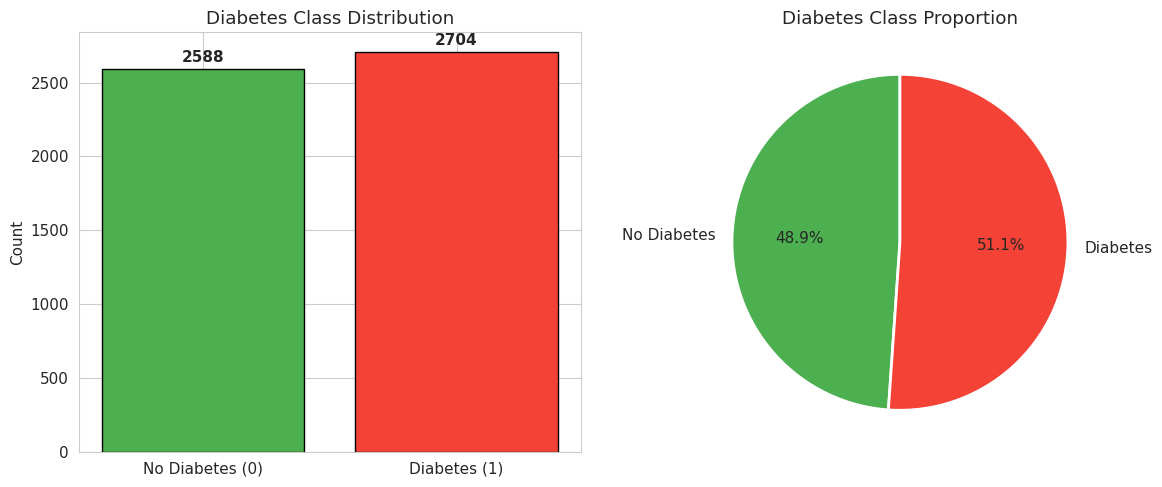

In [103]:
# Check distribution of target variable (Diabetes_Status)
vc = df_india['Diabetes_Status'].value_counts()
# Bar and pie plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Bar chart
bars = axes[0].bar(['No Diabetes (0)', 'Diabetes (1)'],
                   [vc.get(0, 0), vc.get(1, 0)],
                   color=['#4CAF50', '#F44336'], edgecolor='black')
axes[0].set_title('Diabetes Class Distribution')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, [vc.get(0, 0), vc.get(1, 0)]):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 50, val, ha='center', fontweight='bold')
# Pie chart
axes[1].pie([vc.get(0, 0), vc.get(1, 0)],
            labels=['No Diabetes', 'Diabetes'],
            colors=['#4CAF50', '#F44336'], autopct='%1.1f%%',
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}, startangle=90)
axes[1].set_title('Diabetes Class Proportion')
plt.tight_layout()
plt.show()

**Exploration of Variables**

We use histograms to see how numerical measures like BMI, glucose levels, or HbA1c are distributed.

We visualise the proportion of binary health indicators like hypertension or thyroid via bar charts.

We use these to identify any extreme values, skewness, and potential outliers

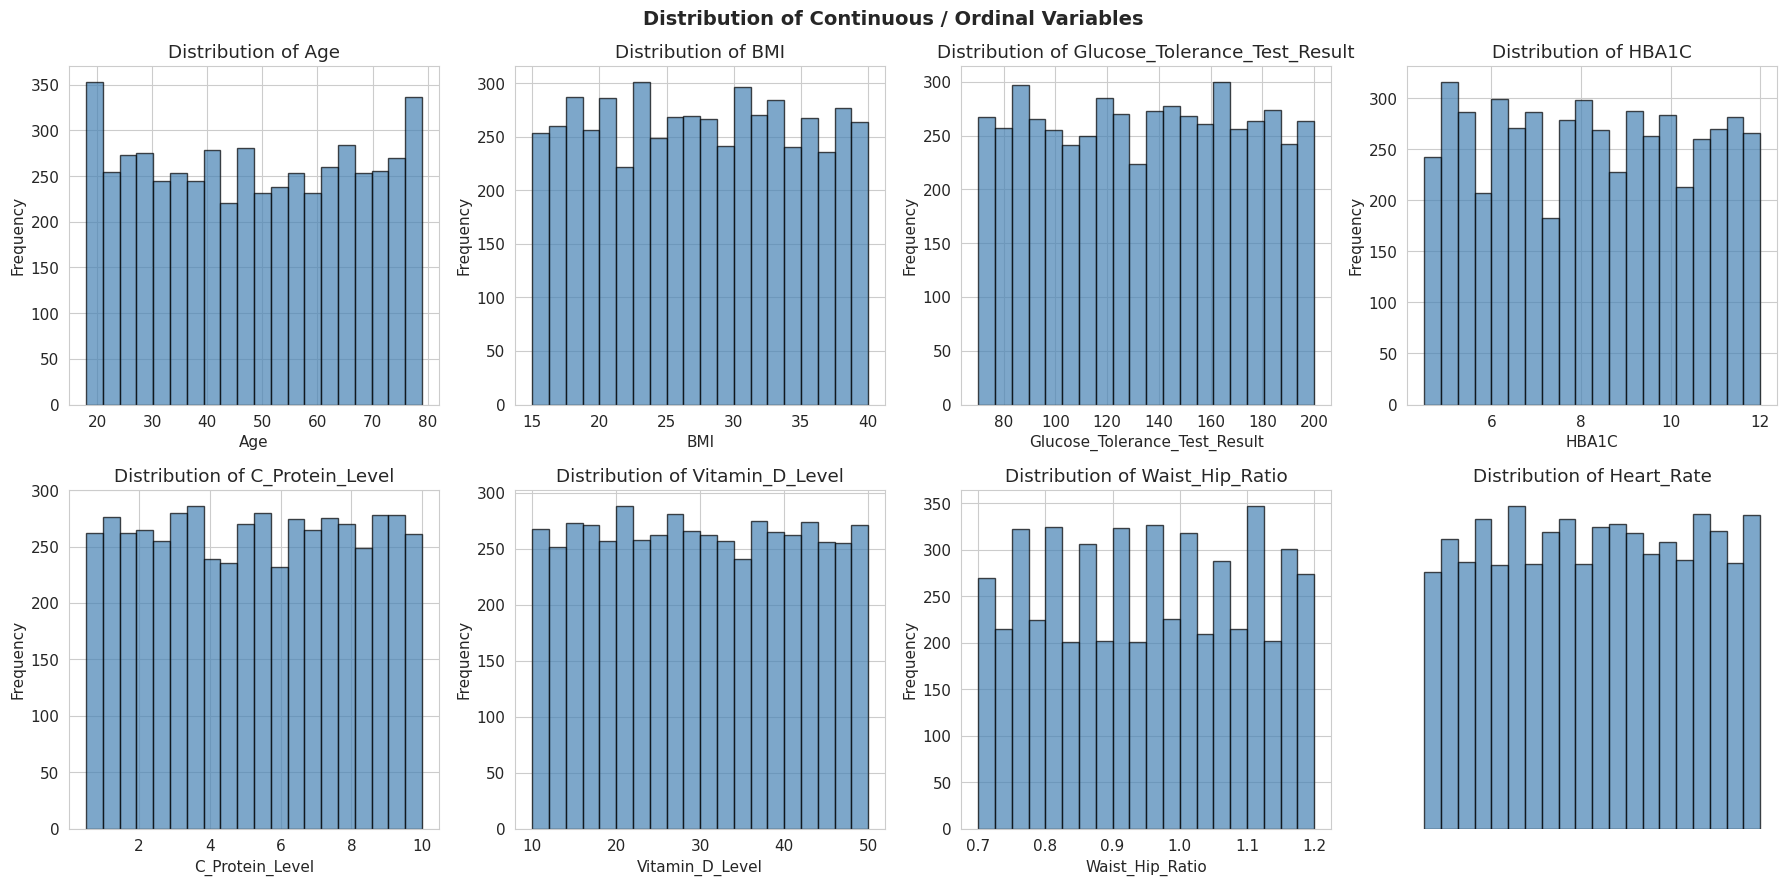

In [104]:
continuous_cols = ['Age', 'BMI', 'Glucose_Tolerance_Test_Result', 'HBA1C',
                   'C_Protein_Level', 'Vitamin_D_Level', 'Waist_Hip_Ratio', 'Heart_Rate']
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, col in enumerate(continuous_cols):
    axes[i].hist(df_india[col].dropna(), bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
axes[-1].axis('off')
plt.suptitle('Distribution of Continuous / Ordinal Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

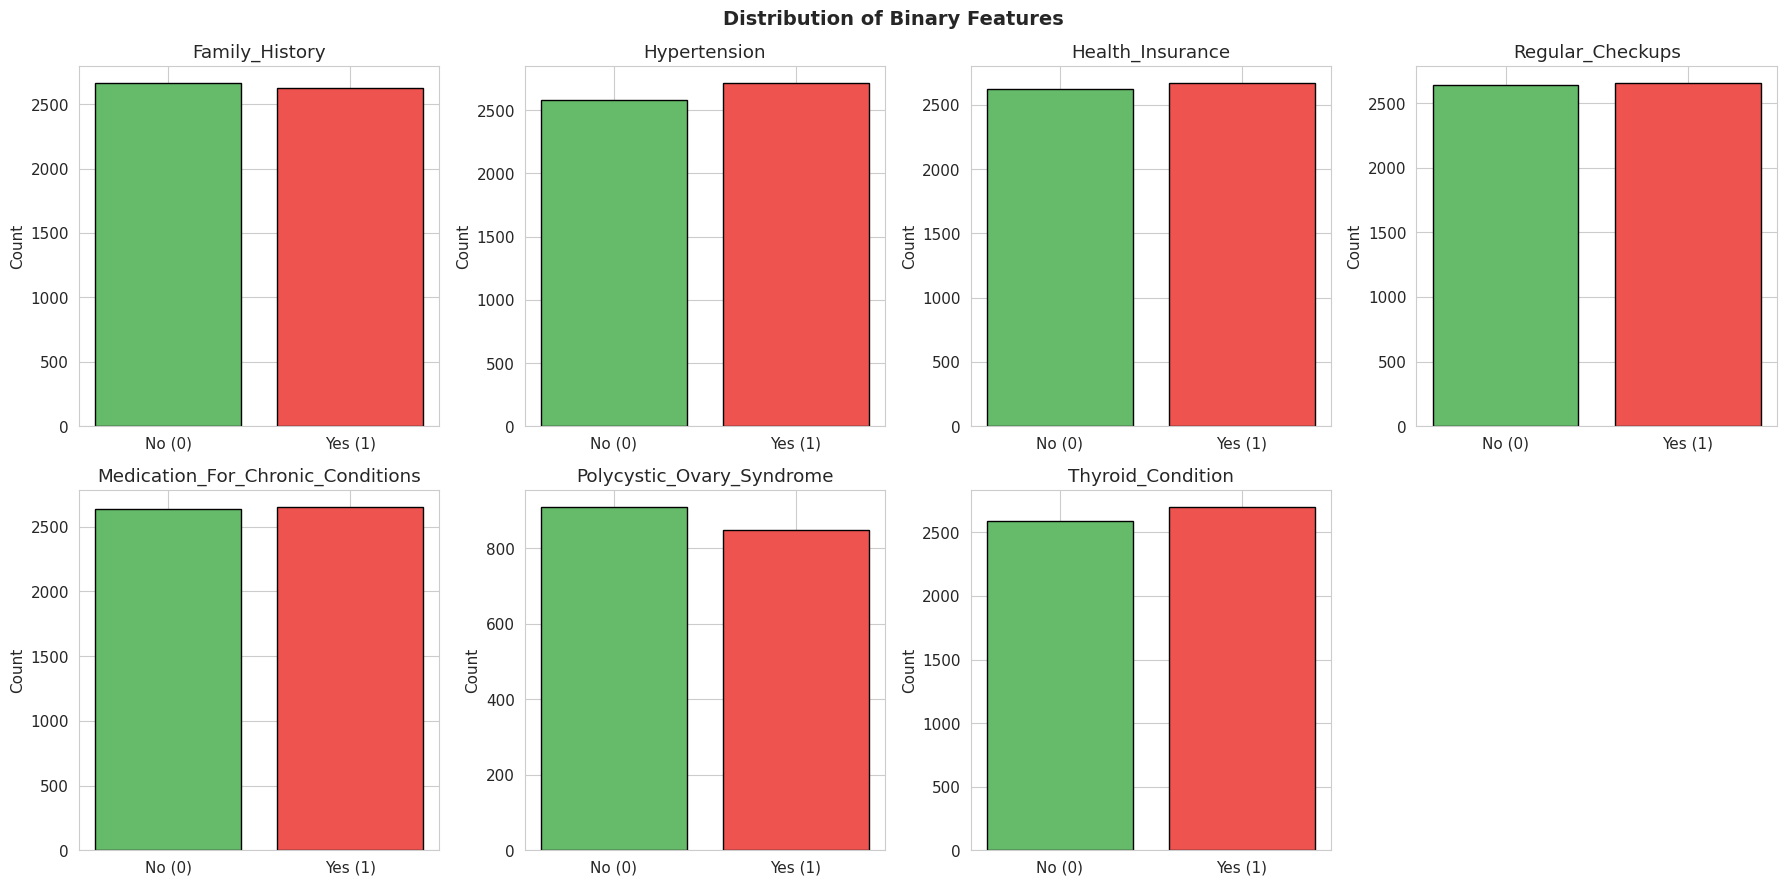

In [105]:
binary_cols = ['Family_History', 'Hypertension', 'Health_Insurance',
               'Regular_Checkups', 'Medication_For_Chronic_Conditions',
               'Polycystic_Ovary_Syndrome', 'Thyroid_Condition']
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, col in enumerate(binary_cols):
    counts = df_india[col].value_counts()
    axes[i].bar(['No (0)', 'Yes (1)'],
                [counts.get(0, 0), counts.get(1, 0)],
                color=['#66BB6A', '#EF5350'], edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')
for j in range(len(binary_cols), len(axes)):
    axes[j].axis('off')
plt.suptitle('Distribution of Binary Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Quality Considerations**

Completeness: The dataset exhibits strong completeness in core clinical variables such as BMI, HbA1c, and blood glucose, with nulls confined to lifestyle fields like AlcoholIntake (34%), enabling targeted imputation during preparation.

Accuracy: Self-reported lifestyle data (e.g., smoking, diet) introduces potential recall bias and inconsistencies, as highlighted in course profiling discussions on disguised missings and validity checks

**Conclusion**

This dataset looks at diabetes risk in the Indian population using a combination of personal, lifestyle, and health-related factors. It also includes information such as diet type, physical activity, smoking, stress level, and regular health checkups, which can help show how daily habits and existing health conditions may be linked to diabetes status.

Moderately suitable for inclusion after cleaning (impute AlcoholIntake, map binaries), despite noted self-report limitations, strong clinical coverage supports risk factor analysis and should be retained for diversity.

## **Dataset 2: Bangladesh diabetes dataset**

**Description:** This dataset contains sign and symptom data of newly diabetic or at‑risk patients, collected via questionnaire at Sylhet Diabetes Hospital in Bangladesh.

In [106]:
df_bangladesh = pd.read_csv('/content/drive/MyDrive/SC3021/bangladesh_diabetes.csv')
print(df_bangladesh.head())

   Age Gender Polyuria Polydipsia sudden weight loss weakness Polyphagia  \
0   40   Male       No        Yes                 No      Yes         No   
1   58   Male       No         No                 No      Yes         No   
2   41   Male      Yes         No                 No      Yes        Yes   
3   45   Male       No         No                Yes      Yes        Yes   
4   60   Male      Yes        Yes                Yes      Yes        Yes   

  Genital thrush visual blurring Itching Irritability delayed healing  \
0             No              No     Yes           No             Yes   
1             No             Yes      No           No              No   
2             No              No     Yes           No             Yes   
3            Yes              No     Yes           No             Yes   
4             No             Yes     Yes          Yes             Yes   

  partial paresis muscle stiffness Alopecia Obesity     class  
0              No              Yes      

**Dimensions and Attributes**  
  
We check how many rows (observations) and list out columns (attributes) which are in the dataset to get a sense of its scale and complexity. This is a very small dataset with 520 rows and 17 columns.

In [107]:
num_rows = df_bangladesh.shape[0]
num_cols = df_bangladesh.shape[1]
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")
print("\nDataset Columns:")
for col in df_bangladesh.columns:
    print("-", col)

Number of rows: 520
Number of columns: 17

Dataset Columns:
- Age
- Gender
- Polyuria
- Polydipsia
- sudden weight loss
- weakness
- Polyphagia
- Genital thrush
- visual blurring
- Itching
- Irritability
- delayed healing
- partial paresis
- muscle stiffness
- Alopecia
- Obesity
- class


**Missing/NULL values**

We check for missing data that might need imputation (mean, median, mode) or removal depending on severity and feature importance.

In [108]:
print(f"This dataset contains missing/NULL values: {df_bangladesh.isnull().any().any()}")
print(f"No missing values were detected so no imputation is required")

This dataset contains missing/NULL values: False
No missing values were detected so no imputation is required


**Data types**

It relies almost entirely on self-reported, qualitative symptoms (e.g., Polyuria, Polydipsia, sudden weight loss) rather than clinical lab results.

Age is the only continuous variable while the rest are "binary" categorical symptoms.

In [109]:
# Convert target 'class' to binary
df_bangladesh['class'] = df_bangladesh['class'].map({'Negative': 0, 'Positive': 1})

# Convert Yes/No symptom columns to binary (0 = No, 1 = Yes)
yes_no_cols = ['Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness',
               'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching',
               'Irritability', 'delayed healing', 'partial paresis',
               'muscle stiffness', 'Alopecia', 'Obesity']
for col in yes_no_cols:
    df_bangladesh[col] = df_bangladesh[col].map({'No': 0, 'Yes': 1})

# Convert Gender to category
df_bangladesh['Gender'] = df_bangladesh['Gender'].astype('category')

print("\nData types after conversion:")
display(df_bangladesh.dtypes)



Data types after conversion:


,0
Age,int64
Gender,category
Polyuria,int64
Polydipsia,int64
sudden weight loss,int64
weakness,int64
Polyphagia,int64
Genital thrush,int64
visual blurring,int64
Itching,int64


**Class Balance for Target variable**

We visualize the target variable (class) using a bar and pie chart to examine class imbalance. In this case, the target is heavily symptom-driven, and shows a noticeable imbalance.

However, this is expected given the dataset was collected at a diabetes hospital specifically from newly diagnosed patients or those already presenting with risk factors.

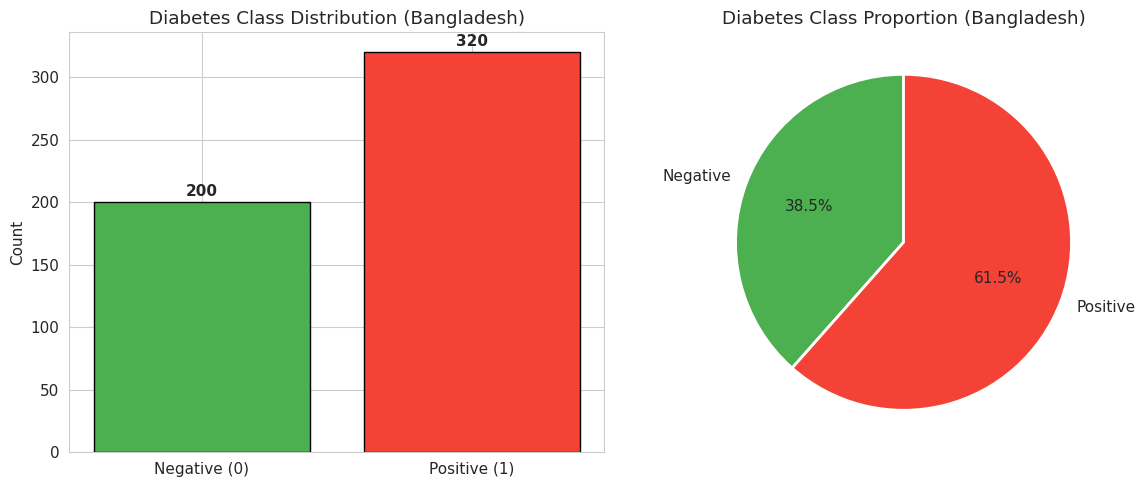

In [110]:
vc = df_bangladesh['class'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
bars = axes[0].bar(['Negative (0)', 'Positive (1)'],
                   [vc.get(0, 0), vc.get(1, 0)],
                   color=['#4CAF50', '#F44336'], edgecolor='black')
axes[0].set_title('Diabetes Class Distribution (Bangladesh)')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, [vc.get(0, 0), vc.get(1, 0)]):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 5, val, ha='center', fontweight='bold')

# Pie chart
axes[1].pie([vc.get(0, 0), vc.get(1, 0)],
            labels=['Negative', 'Positive'],
            colors=['#4CAF50', '#F44336'], autopct='%1.1f%%',
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}, startangle=90)
axes[1].set_title('Diabetes Class Proportion (Bangladesh)')
plt.tight_layout()
plt.show()

**Exploration of Variables**

We use histograms to see how numerical measures like (insert attribute names) are distributed.

We visualise the proportion of binary health indicators like (insert attribute names) via bar charts.

We use these to identify any extreme values, skewness, and potential outliers

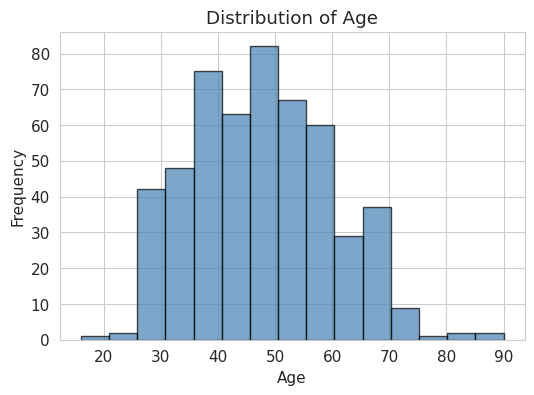

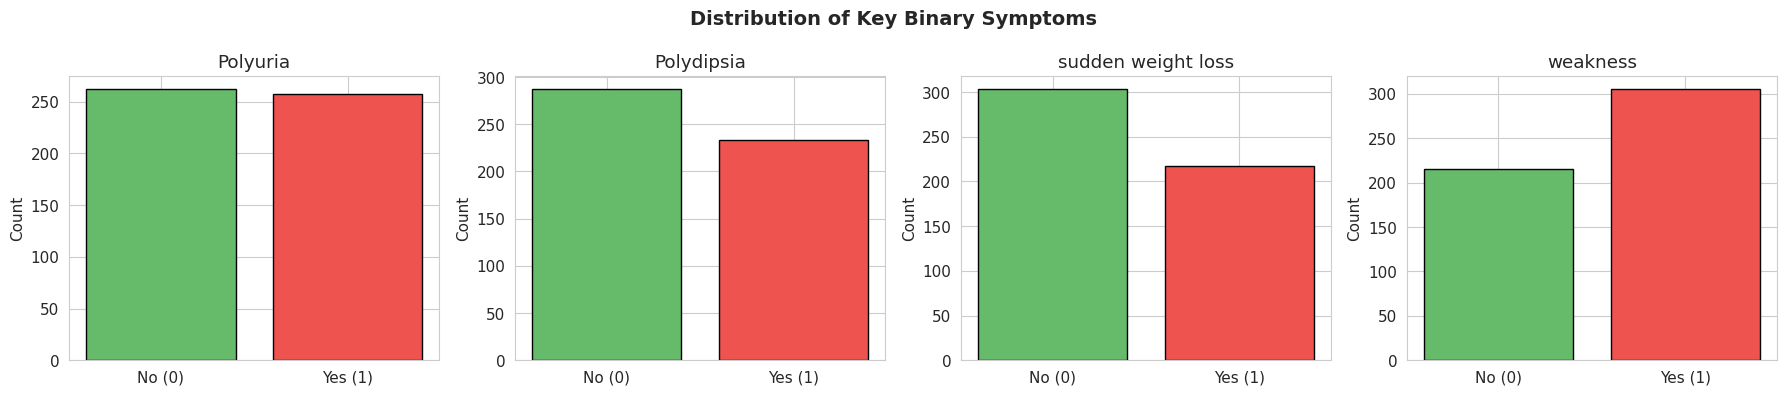

In [111]:
# Only Age is continuous in this dataset as mentioned in data type
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df_bangladesh['Age'].dropna(), bins=15, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_title('Distribution of Age')
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
plt.show()

# Plot key binary symptoms
key_symptoms = ['Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes = axes.flatten()
for i, col in enumerate(key_symptoms):
    counts = df_bangladesh[col].value_counts()
    axes[i].bar(['No (0)', 'Yes (1)'],
                [counts.get(0, 0), counts.get(1, 0)],
                color=['#66BB6A', '#EF5350'], edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')
plt.suptitle('Distribution of Key Binary Symptoms', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Quality Considerations**

Completeness: No missing values across all 17 symptom variables, providing a fully populated dataset ready for immediate structuring without imputation needs.

Relevance: Predominantly subjective symptom data lacks objective clinical metrics (e.g., BMI, HbA1c), limiting its alignment with analytical requirements for measurable risk factors.

**Conclusion**

This dataset, collected from patients at Sylhet Diabetes Hospital in Sylhet, Bangladesh, focuses on the signs and symptoms of newly diagnosed diabetic patients or those at risk of developing diabetes. By emphasizing early warning signs rather than lab results, it enables identification of at-risk individuals before clinical diagnosis.

The inclusion of less common symptoms like genital thrush and partial paresis may reveal interesting patterns, though self-reported data could introduce bias and lifestyle factors such as diet or exercise are not included.

Ultimately, unsuitable due to small size (520 rows) and lack of clinical vars.

## Dataset 3: USA BRFSS diabetes dataset

**Description:** This dataset aggregates 253k+ BRFSS 2015 survey responses in the USA, including lifestyle, comorbidities, and health indicators, and includes a diabetes label derived from survey responses.

In [112]:
df_USA_BRFSS = pd.read_csv('/content/drive/MyDrive/SC3021/AMERICAA_diabetes.csv')
print(df_USA_BRFSS.head())

   Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0              0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1              0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2              0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3              0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4              0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.0       1.0  0.0   9.0   

**Dimensions and Attributes**  
  
We check how many rows (observations) and list out columns (attributes) which are in the dataset to get a sense of its scale and complexity.

In [113]:
num_rows = df_USA_BRFSS.shape[0]
num_cols = df_USA_BRFSS.shape[1]
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")
print(f"\nDataset Columns:")
for i in df_USA_BRFSS.columns:
  print("- "+ i)

Number of rows: 253680
Number of columns: 22

Dataset Columns:
- Diabetes_binary
- HighBP
- HighChol
- CholCheck
- BMI
- Smoker
- Stroke
- HeartDiseaseorAttack
- PhysActivity
- Fruits
- Veggies
- HvyAlcoholConsump
- AnyHealthcare
- NoDocbcCost
- GenHlth
- MentHlth
- PhysHlth
- DiffWalk
- Sex
- Age
- Education
- Income


**Missing/NULL values**

We check for missing data that might need imputation (mean, median, mode) or removal depending on severity and feature importance.

In [114]:
print(f"This dataset contains missing/NULL values: {df_USA_BRFSS.isnull().any().any()}")
print(f"No missing values were detected so no imputation is required")

This dataset contains missing/NULL values: False
No missing values were detected so no imputation is required


Initial programmatic checks may flag this dataset as complete. However, survey-based datasets frequently utilize dummy values (such as "None", "Refused", or "Don't Know") to represent missing answers in categorical columns.

These semantic missing values must be identified and corrected during the data cleaning stage to prevent models from learning erroneous patterns.

**Data types**

All columns are currently float64, but most are binary (0/1) or categorical integers.

In [115]:
display(df_USA_BRFSS.dtypes)


,0
Diabetes_binary,float64
HighBP,float64
HighChol,float64
CholCheck,float64
BMI,float64
Smoker,float64
Stroke,float64
HeartDiseaseorAttack,float64
PhysActivity,float64
Fruits,float64


**Class Balance for Target variable**

We visualize the target variable (Diabetes_Status) using a bar and pie chart to examine class imbalance. In this case, the dataset is imbalanced, with 86.1% non-diabetic and 13.9% diabetic cases.

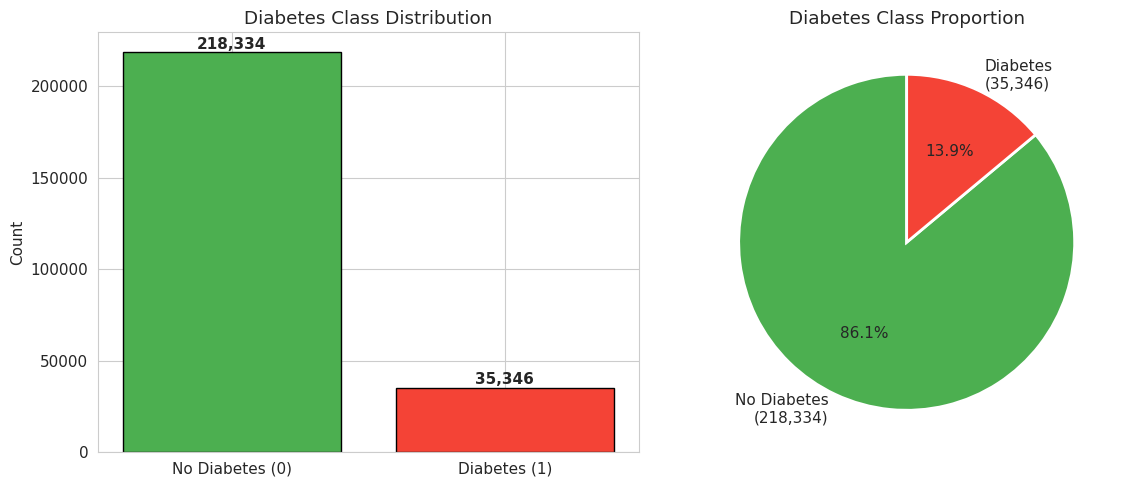

In [116]:
vc = df_USA_BRFSS['Diabetes_binary'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
bars = axes[0].bar(['No Diabetes (0)', 'Diabetes (1)'], [vc[0], vc[1]],
                    color=['#4CAF50', '#F44336'], edgecolor='black')
axes[0].set_ylabel('Count')
axes[0].set_title('Diabetes Class Distribution')
for bar, val in zip(bars, [vc[0], vc[1]]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'{val:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie([vc[0], vc[1]],
            labels=[f'No Diabetes\n({vc[0]:,})', f'Diabetes\n({vc[1]:,})'],
            colors=['#4CAF50', '#F44336'], autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Diabetes Class Proportion')

plt.tight_layout()
plt.show()

**Exploration of Variables**

We use histograms to examine the distribution of continuous and ordinal variables like BMI, Age, Physical Health are distributed.

We visualise the proportion of the majority binary attributes to understand how common each health condition or behaviour is in the surveyed population. For example, we can see that 43% of respondents have high blood pressure and 44% are smokers.

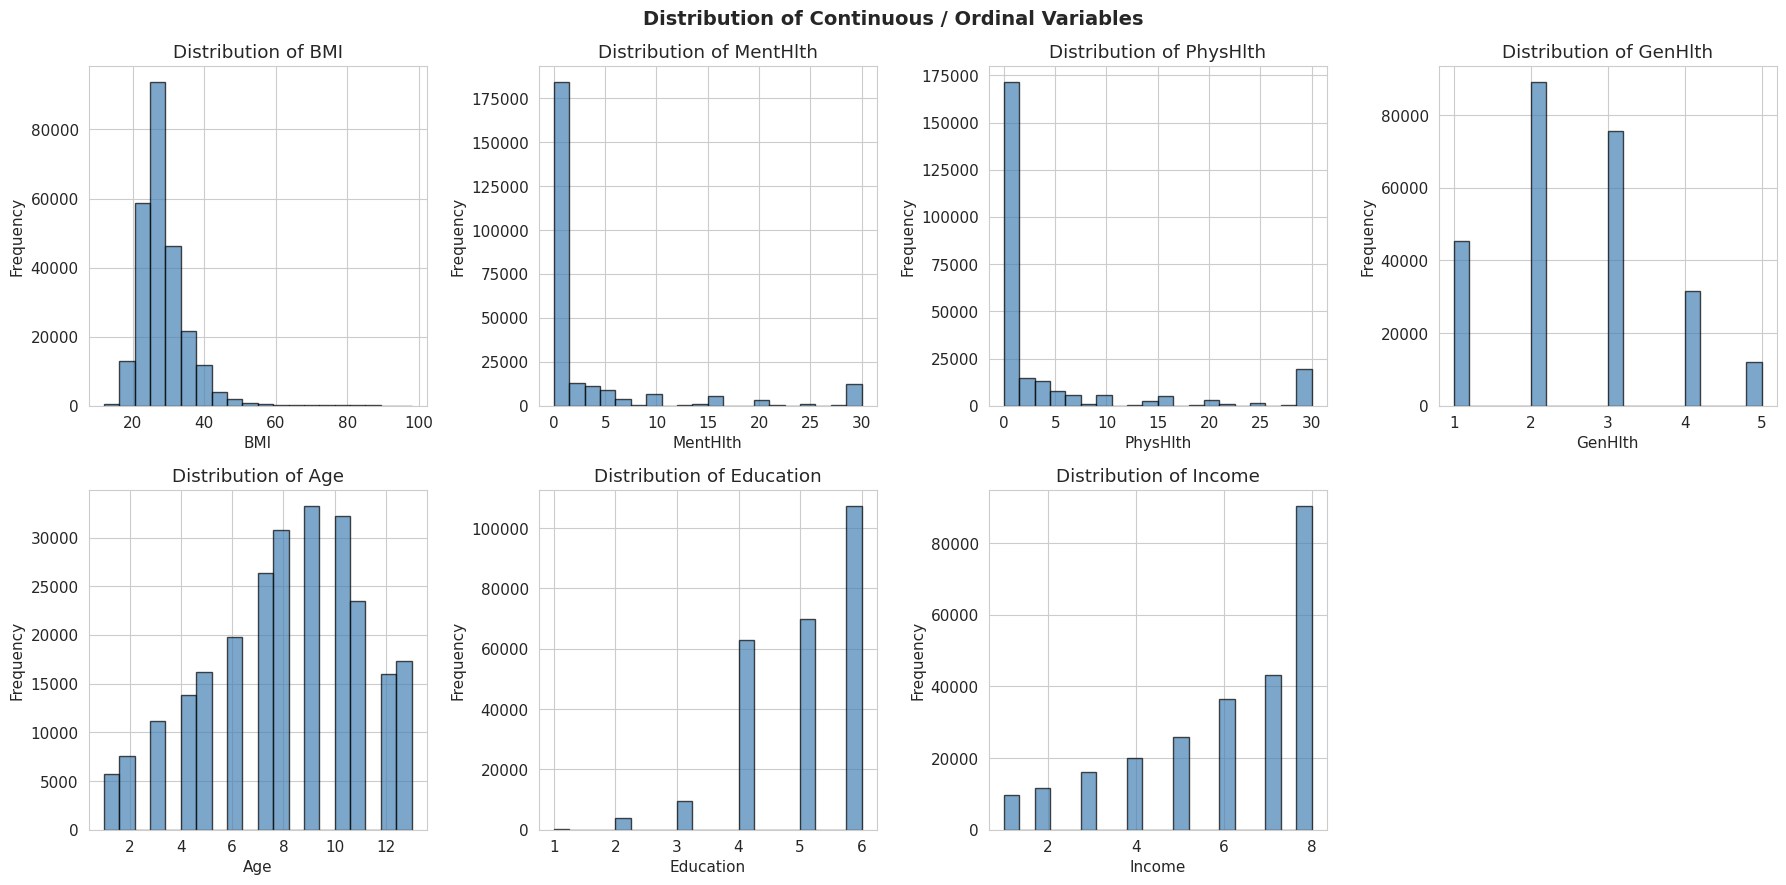

In [117]:
continuous_cols = ['BMI', 'MentHlth', 'PhysHlth', 'GenHlth', 'Age', 'Education', 'Income']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    axes[i].hist(df_USA_BRFSS[col].dropna(), bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

axes[-1].axis('off')
plt.suptitle('Distribution of Continuous / Ordinal Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

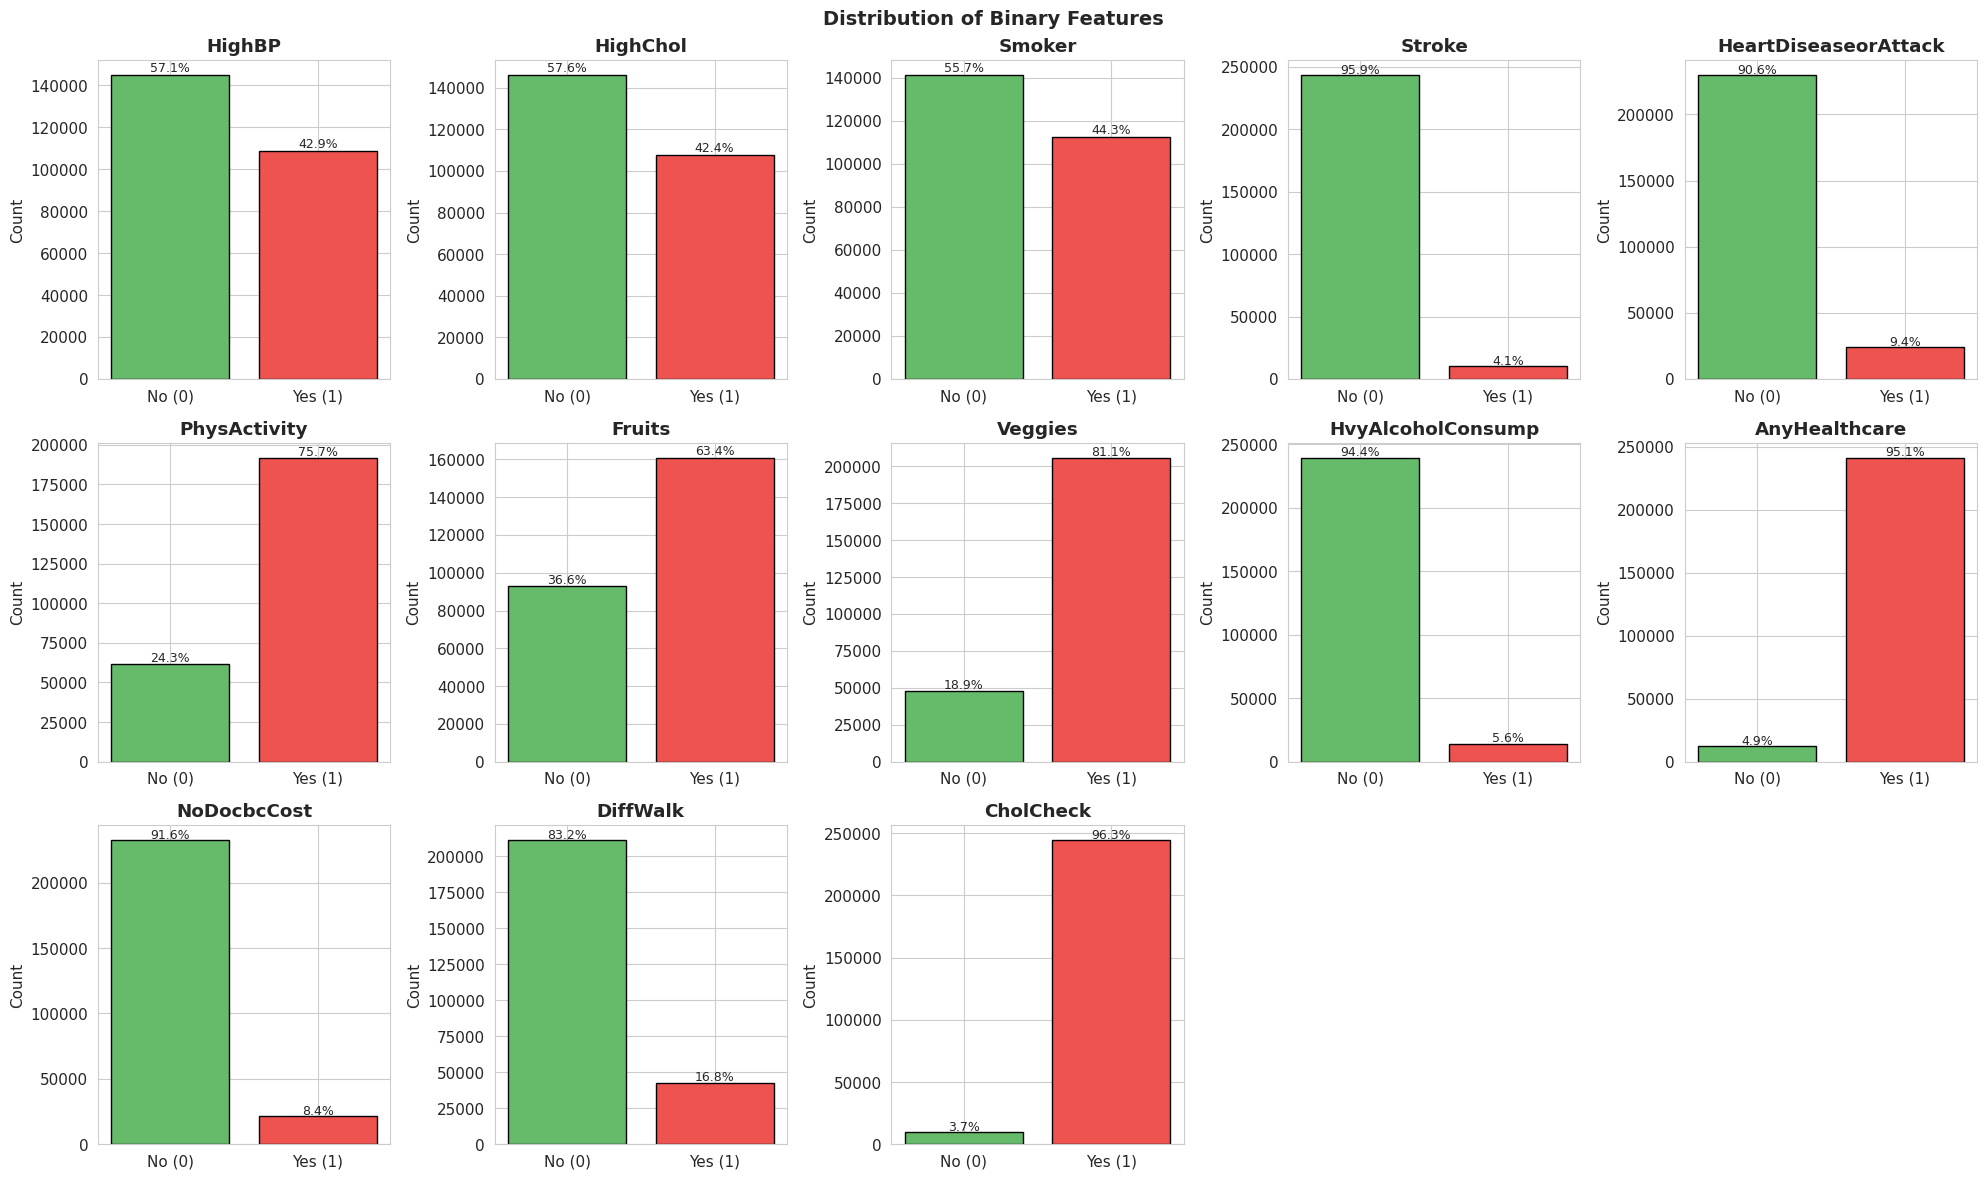

In [118]:
binary_cols = ['HighBP', 'HighChol', 'Smoker', 'Stroke', 'HeartDiseaseorAttack',
               'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump',
               'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'CholCheck']

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    counts = df_USA_BRFSS[col].value_counts()
    axes[i].bar(['No (0)', 'Yes (1)'], [counts.get(0, 0), counts.get(1, 0)],
                color=['#66BB6A', '#EF5350'], edgecolor='black')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Count')
    total = len(df_USA_BRFSS)
    for j, val in enumerate([counts.get(0, 0), counts.get(1, 0)]):
        axes[i].text(j, val + 1500, f'{val/total*100:.1f}%', ha='center', fontsize=9)

for j in range(len(binary_cols), len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribution of Binary Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Quality Considerations**

Volume/Completeness: Exceptional scale (253k rows) ensures robust coverage of demographics and comorbidities, supporting reliable aggregation and pattern detection.

Accuracy: Survey-based responses suffer from recall bias and disguised missings (e.g., "Refused"), undermining reliability for precise diabetes prediction.

**Conclusion**

This dataset comes from the 2015 Behavioral Risk Factor Surveillance System, which includes information on clinical factors, lifestyle behaviors, mental and physical health, and socioeconomic background, allowing for a wide-ranging analysis of diabetes risk.

The data also covers access to healthcare and preventive services, which makes it possible to explore health disparities. With three categories of diabetes no diabetes, prediabetes, and diabetes the dataset supports detailed modeling and helps identify early warning signs of the disease.

It is ultimately unsuitable despite size due to pervasive survey bias and should not be considered for this project.

## Dataset 4: Indonesia diabetes dataset

**Description:** This dataset contains 100,000 de‑identified patient records with demographic and clinical variables

In [119]:
df_Indonesia = pd.read_csv('/content/drive/MyDrive/SC3021/Indonesia_diabetes_prediction_dataset.csv')
print(df_Indonesia.head())

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


**Dimensions and Attributes**  
  
We check how many rows (observations) and list out columns (attributes) which are in the dataset to get a sense of its scale and complexity.

In [120]:
num_rows = df_Indonesia.shape[0]
num_cols = df_Indonesia.shape[1]
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")
print(f"\nDataset Columns:")
for i in df_Indonesia.columns:
  print("- "+ i)

Number of rows: 100000
Number of columns: 9

Dataset Columns:
- gender
- age
- hypertension
- heart_disease
- smoking_history
- bmi
- HbA1c_level
- blood_glucose_level
- diabetes


**Missing/NULL values**

We check for missing data that might need imputation (mean, median, mode) or removal depending on severity and feature importance.

In [121]:
print(f"This dataset contains missing/NULL values: {df_Indonesia.isnull().any().any()}")
print(f"No missing values were detected so no imputation is required")

This dataset contains missing/NULL values: False
No missing values were detected so no imputation is required


While initial profiling indicates zero missing or standard NULL values, closer inspection reveals that the categorical feature smoking_history contains a "No Info" category.

This dummy value will need to be explicitly addressed during the Data Cleaning phase—either via imputation or by treating it as a distinct categorical feature, depending on its prevalence.

**Data types**
It provides a strong mix of continuous clinical metrics (Age, BMI, HbA1c, blood glucose) and categorical risk factors (Gender, smoking history, hypertension, heart disease).

In [122]:
# Convert categorical columns to category dtype
cat_cols = ['gender', 'smoking_history']
for col in cat_cols:
    df_Indonesia[col] = df_Indonesia[col].astype('category')

display(df_Indonesia.dtypes)

,0
gender,category
age,float64
hypertension,int64
heart_disease,int64
smoking_history,category
bmi,float64
HbA1c_level,float64
blood_glucose_level,int64
diabetes,int64


**Class Balance for Target variable**

We visualize the target variable (diabetes) using a bar and pie chart to examine class imbalance. The target variable here is highly imbalanced, with the vast majority of records belonging to "No Diabetes" .

Because overall incidence rate of diabetes in a general population is relatively low, this reflects real-world distributions. However, from a machine learning perspective, training on this data without intervention will result in a model biased toward negative predictions.

Resampling techniques (such as undersampling the majority class or oversampling the minority class) or reduction of dataset weight in final prediciton model will be essential.

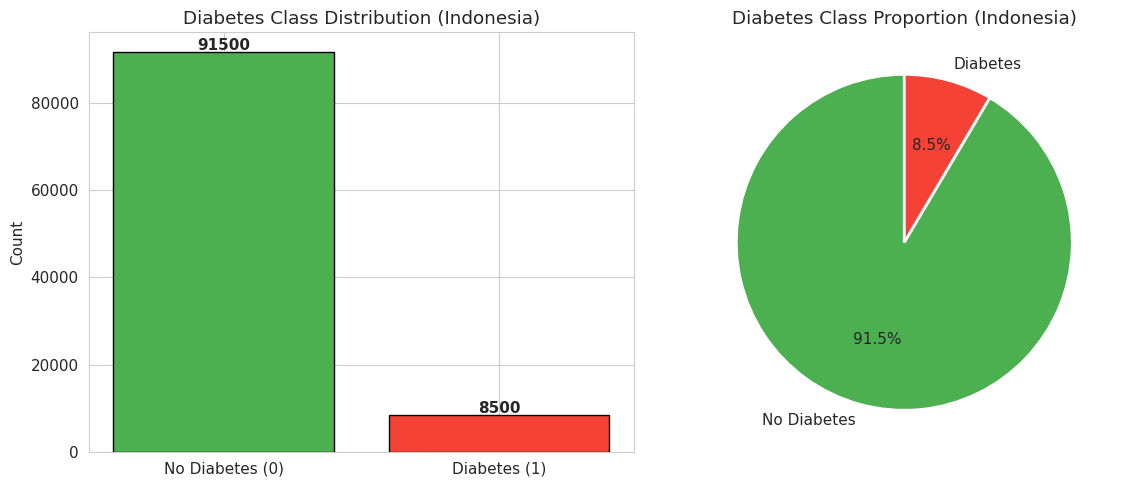

In [123]:
vc = df_Indonesia['diabetes'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars = axes[0].bar(['No Diabetes (0)', 'Diabetes (1)'],
                   [vc.get(0, 0), vc.get(1, 0)],
                   color=['#4CAF50', '#F44336'], edgecolor='black')
axes[0].set_title('Diabetes Class Distribution (Indonesia)')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, [vc.get(0, 0), vc.get(1, 0)]):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 500, val, ha='center', fontweight='bold')

axes[1].pie([vc.get(0, 0), vc.get(1, 0)],
            labels=['No Diabetes', 'Diabetes'],
            colors=['#4CAF50', '#F44336'], autopct='%1.1f%%',
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}, startangle=90)
axes[1].set_title('Diabetes Class Proportion (Indonesia)')
plt.tight_layout()
plt.show()

**Exploration of Variables**

We use histograms to see how numerical measures like age, bmi, HbA1c_level, and blood_glucose_level are distributed.

We visualise the proportion of binary health indicators like hypertension and heart_disease via bar charts.

Certain categorical variables, specifically smoking_history, contain ambiguous categories like "No Info", which will require careful handling or encoding during the data preparation phase.

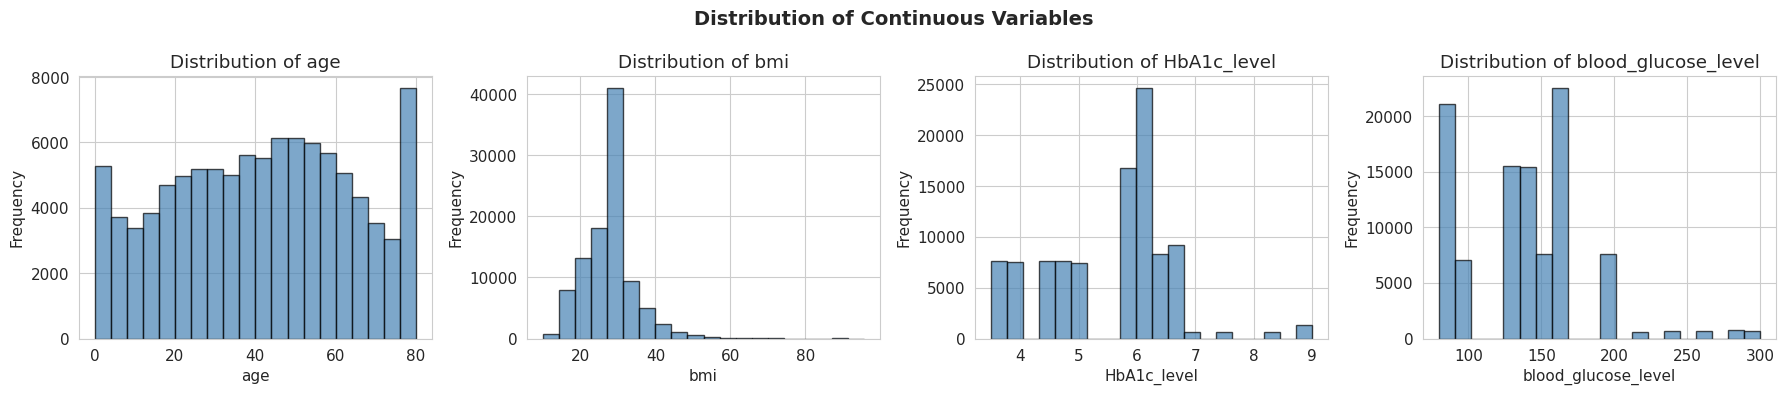

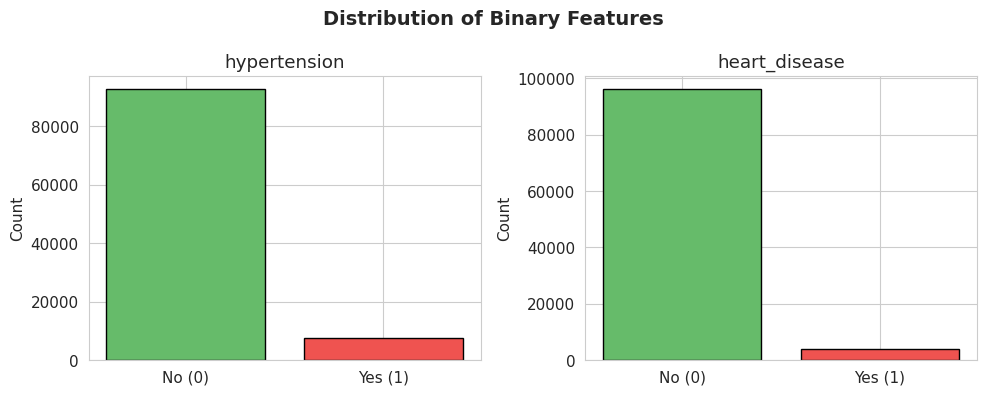

In [124]:
continuous_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes = axes.flatten()
for i, col in enumerate(continuous_cols):
    axes[i].hist(df_Indonesia[col].dropna(), bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.suptitle('Distribution of Continuous Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

binary_cols = ['hypertension', 'heart_disease']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.flatten()
for i, col in enumerate(binary_cols):
    counts = df_Indonesia[col].value_counts()
    axes[i].bar(['No (0)', 'Yes (1)'],
                [counts.get(0, 0), counts.get(1, 0)],
                color=['#66BB6A', '#EF5350'], edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')
plt.suptitle('Distribution of Binary Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Quality Considerations**

Completeness: Zero explicit nulls post-duplicate removal (96k rows), with clinical core (HbA1c, glucose) fully intact for direct analysis.

Accuracy: "No Info" in smoking (34%) acts as disguised missing, necessitating mapping or imputation to avoid skewing lifestyle-risk correlations.

**Conclusion**

This Indonesia diabetes dataset contains individual-level records and includes key risk factors such as age, BMI, HbA1c level, blood glucose level, as well as hypertension, heart disease, gender, and smoking history.

The target variable diabetes is binary (0/1), making it suitable for supervised classification to estimate diabetes risk.

It is highly suitable due to excellent scale/clinical focus ideal for core modeling. Can be applied after smoking mapping is handled in Data Preparation

## **Dataset 5: Pima Indians diabetes dataset**

**Description:** This dataset contains medical measurements of female Pima Indian patients aged ≥21 years from the National Institute of Diabetes and Digestive and Kidney Diseases.

In [125]:
df_pima = pd.read_csv('/content/drive/MyDrive/SC3021/pima_indians_diabetes.csv')
print(df_pima.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


**Dimensions and Attributes**  
  
We check how many rows (observations) and list out columns (attributes) which are in the dataset to get a sense of its scale and complexity.

In [126]:
num_rows = df_pima.shape[0]
num_cols = df_pima.shape[1]
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")
print(f"\nDataset Columns:")
for i in df_pima.columns:
  print("- "+ i)

Number of rows: 768
Number of columns: 9

Dataset Columns:
- Pregnancies
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI
- DiabetesPedigreeFunction
- Age
- Outcome


**Missing/NULL values**

We check for missing data that might need imputation (mean, median, mode) or removal depending on severity and feature importance.

This dataset contains explicit missing/NULL values: False
Zeros found in non-binary attributes (%):
Glucose           0.651042
BloodPressure     4.557292
SkinThickness    29.557292
Insulin          48.697917
BMI               1.432292
dtype: float64

 Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


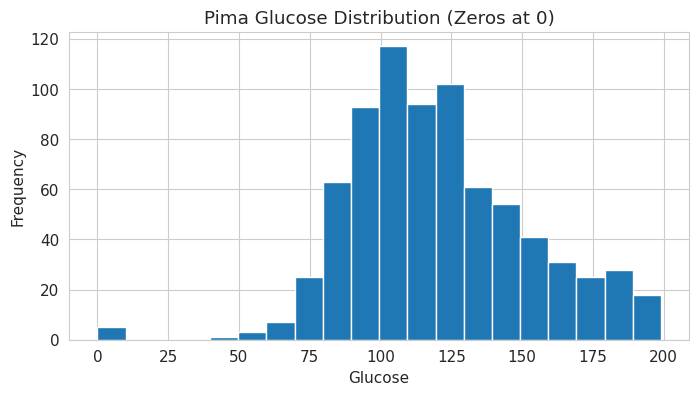

In [127]:
print(f"This dataset contains explicit missing/NULL values: {df_pima.isnull().any().any()}")
print("Zeros found in non-binary attributes (%):")
zeros_pct = (df_pima[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] == 0).mean() * 100
print(zeros_pct)

print(f"\n",df_pima['Outcome'].value_counts(normalize=True).round(3))

plt.figure(figsize=(8,4))
df_pima['Glucose'].hist(bins=20)
plt.xlabel('Glucose')
plt.ylabel('Frequency')
plt.title('Pima Glucose Distribution (Zeros at 0)')
plt.show()

While the dataset registers False for standard NULL values, profiling reveals explicit missing data encoded as zeroes in biological measurements which are physiologically impossible and must be treated as missing values.

**Data types**
The dataset consists entirely of numerical, clinical-grade measurements.

It includes a unique continuous feature, the DiabetesPedigreeFunction, which mathematically quantifies genetic predisposition.

In [128]:
display(df_pima.dtypes)

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


**Class Balance for Target variable**

We visualize the target variable (diabetes) using a bar and pie chart to examine class imbalance. In this case, there is moderate class imbalance.

While this imbalance is not as extreme as seen in general population datasets, it is still significant enough that it should be monitored during model evaluation.

The higher-than-average baseline prevalence of diabetes in this specific demographic explains why the minority class is still relatively well-represented.

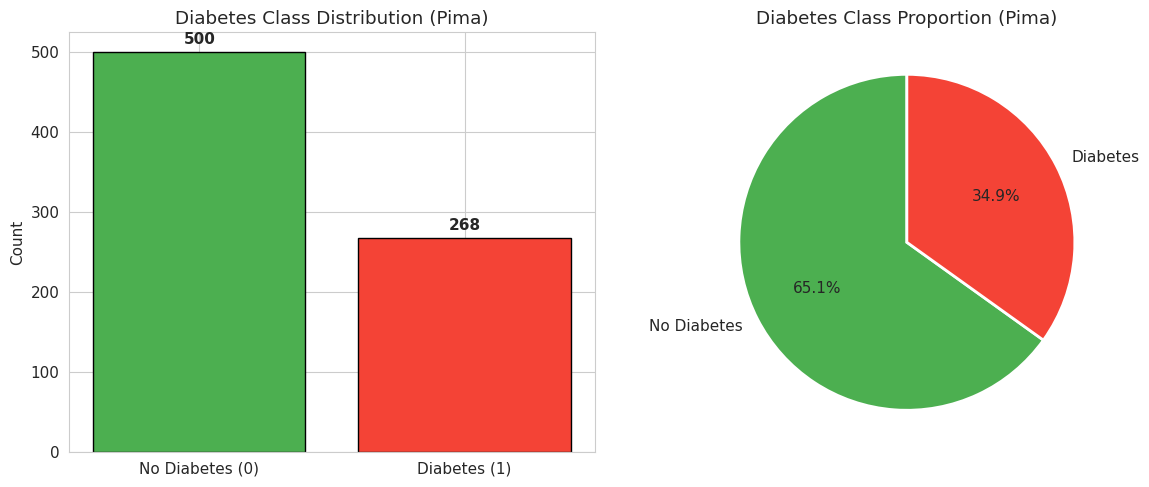

In [129]:
vc = df_pima['Outcome'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars = axes[0].bar(['No Diabetes (0)', 'Diabetes (1)'],
                   [vc.get(0, 0), vc.get(1, 0)],
                   color=['#4CAF50', '#F44336'], edgecolor='black')
axes[0].set_title('Diabetes Class Distribution (Pima)')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, [vc.get(0, 0), vc.get(1, 0)]):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 10, val, ha='center', fontweight='bold')

axes[1].pie([vc.get(0, 0), vc.get(1, 0)],
            labels=['No Diabetes', 'Diabetes'],
            colors=['#4CAF50', '#F44336'], autopct='%1.1f%%',
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}, startangle=90)
axes[1].set_title('Diabetes Class Proportion (Pima)')
plt.tight_layout()
plt.show()

**Exploration of Variables**

We use histograms to see how numerical measures are distributed.

Here, outliers due to zeroes representing Null value are clearly seen. This could affect resulting statistics like mean, median if not handled early.

The demographic scope is highly restricted, representing only females aged 21 and older of Pima Indian heritage, which limits the model's generalizability to broader populations.

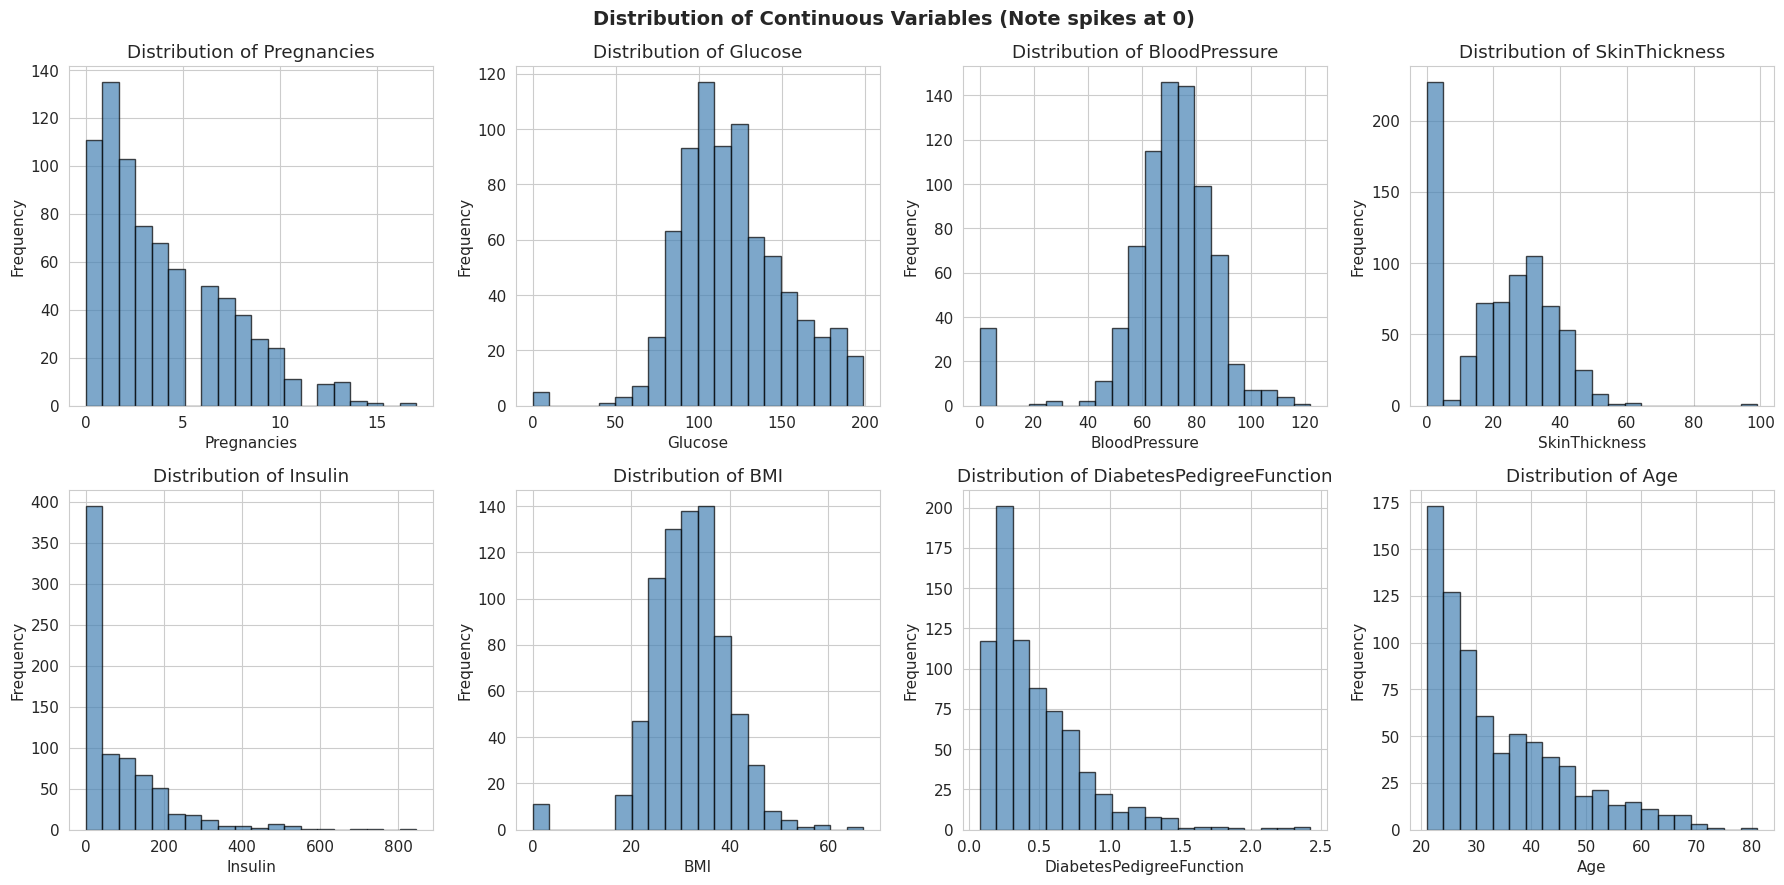

In [130]:
continuous_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                   'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, col in enumerate(continuous_cols):
    # We plot the raw data, which will visually reveal the physiological 0s
    axes[i].hist(df_pima[col].dropna(), bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.suptitle('Distribution of Continuous Variables (Note spikes at 0)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Quality Considerations**

Reputation: Sourced from reputable NIH/UCI benchmark, offering validated clinical measurements trusted for diabetes research reproducibility.

Accuracy: Physiological impossibilities like BMI=0 (50%) and Glucose=0 (30%) represent disguised missings, requiring correction for valid range enforcement.

**Conclusion**

This dataset focuses on a specific population, Pima Indian heritage with high diabetes prevalence, making it valuable for studying genetic predisposition. The diabetes pedigree function is a unique feature that quantifies family history using a specialized algorithm. The glucose tolerance test results also provide clinical-grade measurements that could be strong predictors.

However, the dataset is extremely small and only includes females aged 21+, which limits generalizability. With heavy disguised missings, it is overall safer to drop in this project's context to avoid demographic skew.

## **Dataset 6: USA NHANES diabetes dataset**

**Description:** This dataset contains official NHANES survey data from the CDC, combining interviews, physical exams, and laboratory tests on ~10,000 US participants per 2-year cycle to assess health/nutrition status across diverse ethnicities.


In [131]:
from functools import reduce

#Load the relevant CSV files
df_demo = pd.read_csv('/content/drive/MyDrive/SC3021/NHANES_demographic.csv')
df_exam = pd.read_csv('/content/drive/MyDrive/SC3021/NHANES_examination.csv')
df_labs = pd.read_csv('/content/drive/MyDrive/SC3021/NHANES_labs.csv')
df_quest = pd.read_csv('/content/drive/MyDrive/SC3021/NHANES_questionnaire.csv')

#Selected only the columns relevant to diabetes factors
demo_cols  = ['SEQN', 'RIDAGEYR', 'RIAGENDR']
exam_cols  = ['SEQN', 'BMXBMI', 'BPXSY1', 'BPXDI1']
labs_cols  = ['SEQN', 'LBXTC']
quest_cols = ['SEQN', 'DIQ010', 'MCQ160C', 'MCQ160E', 'SMQ040',
              'BPQ050A', 'BPQ080', 'PAQ605', 'PAQ650', 'PAQ620']

df_demo = df_demo[demo_cols]
df_exam = df_exam[exam_cols]
df_labs = df_labs[labs_cols]
df_quest = df_quest[quest_cols]
dataframes = [df_demo, df_exam, df_labs, df_quest]

# Create a temporary data frame for quality considerationds; Inner Join of all dataframes on 'SEQN'
df_USA_NHANES = reduce(lambda left, right: pd.merge(left, right, on='SEQN', how='inner'), dataframes)

rename_dict = {
    'SEQN': 'patient_id (SEQN)',
    'RIDAGEYR': 'age_years (RIDAGEYR)',
    'RIAGENDR': 'gender_code (RIAGENDR)',
    'BMXBMI': 'bmi (BMXBMI)',
    'BPXSY1': 'systolic_bp (BPXSY1)',
    'BPXDI1': 'diastolic_bp (BPXDI1)',
    'LBXTC': 'total_cholesterol (LBXTC)',
    'DIQ010': 'diabetes_status (DIQ010)',
    'MCQ160C': 'coronary_heart_disease (MCQ160C)',
    'MCQ160E': 'heart_attack (MCQ160E)',
    'SMQ040': 'current_smoker_status (SMQ040)',
    'BPQ050A': 'taking_bp_meds (BPQ050A)',
    'BPQ080': 'taking_cholesterol_meds (BPQ080)',
    'PAQ605': 'vigorous_work_activity (PAQ605)',
    'PAQ650': 'vigorous_recreational_activity (PAQ650)',
    'PAQ620': 'moderate_work_activity (PAQ620)'
}

existing_renames = {k: v for k, v in rename_dict.items() if k in df_USA_NHANES.columns}
df_USA_NHANES.rename(columns=existing_renames, inplace=True)

print(df_USA_NHANES.head())

   patient_id (SEQN)  age_years (RIDAGEYR)  gender_code (RIAGENDR)  \
0              73557                    69                       1   
1              73558                    54                       1   
2              73559                    72                       1   
3              73560                     9                       1   
4              73561                    73                       2   

   bmi (BMXBMI)  systolic_bp (BPXSY1)  diastolic_bp (BPXDI1)  \
0          26.7                 122.0                   72.0   
1          28.6                 156.0                   62.0   
2          28.9                 140.0                   90.0   
3          17.1                 108.0                   38.0   
4          19.7                 136.0                   86.0   

   total_cholesterol (LBXTC)  diabetes_status (DIQ010)  \
0                      167.0                       1.0   
1                      170.0                       1.0   
2                   

**Dimensions and Attributes**  
  
We check how many rows (observations) and list out columns (attributes) which are in the dataset to get a sense of its scale and complexity.

In [132]:
num_rows = df_USA_NHANES.shape[0]
num_cols = df_USA_NHANES.shape[1]
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")
print(f"\nDataset Columns:")
for i in df_USA_NHANES.columns:
  print("- "+ i)

Number of rows: 9813
Number of columns: 16

Dataset Columns:
- patient_id (SEQN)
- age_years (RIDAGEYR)
- gender_code (RIAGENDR)
- bmi (BMXBMI)
- systolic_bp (BPXSY1)
- diastolic_bp (BPXDI1)
- total_cholesterol (LBXTC)
- diabetes_status (DIQ010)
- coronary_heart_disease (MCQ160C)
- heart_attack (MCQ160E)
- current_smoker_status (SMQ040)
- taking_bp_meds (BPQ050A)
- taking_cholesterol_meds (BPQ080)
- vigorous_work_activity (PAQ605)
- vigorous_recreational_activity (PAQ650)
- moderate_work_activity (PAQ620)


While this inner-joined dataframe reduces the overall row count compared to the raw data, it yields a highly robust, multi-dimensional dataset containing both objective clinical measurements (e.g., bmi, total_cholesterol, systolic_bp) and subjective lifestyle factors.

**Missing/NULL values**

We check for missing data that might need imputation (mean, median, mode) or removal depending on severity and feature importance.

In [133]:
missing_values = df_USA_NHANES.isnull().sum()
print(f"This dataset contains missing/NULL values: {df_USA_NHANES.isnull().any().any()}")
print("Missing values per column:\n", missing_values[missing_values > 0])

This dataset contains missing/NULL values: True
Missing values per column:
 bmi (BMXBMI)                                758
systolic_bp (BPXSY1)                       2641
diastolic_bp (BPXDI1)                      2641
total_cholesterol (LBXTC)                  2189
diabetes_status (DIQ010)                    392
coronary_heart_disease (MCQ160C)           4225
heart_attack (MCQ160E)                     4225
current_smoker_status (SMQ040)             7323
taking_bp_meds (BPQ050A)                   8044
taking_cholesterol_meds (BPQ080)           3547
vigorous_work_activity (PAQ605)            2863
vigorous_recreational_activity (PAQ650)    2864
moderate_work_activity (PAQ620)            2863
dtype: int64


In [134]:
# Function to flag common dummy values across numerical/categorical survey data
def check_dummy_values(df, columns):
    for col in columns:
        # Check for values commonly used as dummy codes in NHANES
        dummies = df[df[col].isin([7, 9, 77, 99, 777, 999])][col].value_counts()
        if not dummies.empty:
            print(f"Dummy values found in '{col}':\n{dummies}\n")

# Check the questionnaire-based columns for these dummies
questionnaire_cols = [
    'diabetes_status (DIQ010)',
    'coronary_heart_disease (MCQ160C)',
    'heart_attack (MCQ160E)',
    'current_smoker_status (SMQ040)',
    'taking_bp_meds (BPQ050A)',
    'taking_cholesterol_meds (BPQ080)'
]
print("--- Disguised Missing Values (Refused/Don't Know) ---")
check_dummy_values(df_USA_NHANES, questionnaire_cols)

--- Disguised Missing Values (Refused/Don't Know) ---
Dummy values found in 'diabetes_status (DIQ010)':
diabetes_status (DIQ010)
9.0    5
7.0    1
Name: count, dtype: int64

Dummy values found in 'coronary_heart_disease (MCQ160C)':
coronary_heart_disease (MCQ160C)
9.0    16
Name: count, dtype: int64

Dummy values found in 'heart_attack (MCQ160E)':
heart_attack (MCQ160E)
9.0    3
Name: count, dtype: int64

Dummy values found in 'taking_bp_meds (BPQ050A)':
taking_bp_meds (BPQ050A)
9.0    1
Name: count, dtype: int64

Dummy values found in 'taking_cholesterol_meds (BPQ080)':
taking_cholesterol_meds (BPQ080)
9.0    36
Name: count, dtype: int64



**Standard Missing Values (NaN):** Objective physical and lab measurements may contain standard NaN values if a specific test was not completed or was deemed invalid by the lab.

**Disguised Dummy Values:** The questionnaire-based columns (such as coronary_heart_disease, current_smoker_status, taking_bp_meds, and activity levels) utilize numerical dummy values to represent non-answers.

Specifically, values like 7 or 77 represent "Refused", while 9 or 99 represent "Don't Know".

If fed into a machine learning model as-is, the model will treat these as large numerical weights rather than missing categorical data. These must be identified and mapped to NaN prior to modeling.

**Data types**
The NHANES dataset primarily uses numerical codes (like 1, 2, 3, 7, 9) rather than "Yes"/"No" strings.



In [135]:
# 1. Convert categorical Yes(1)/No(2) columns to binary (0 = No, 1 = Yes)
binary_mapping = {1: 1, 2: 0}

yes_no_cols = ['coronary_heart_disease', 'heart_attack', 'taking_bp_meds', 'taking_cholesterol_meds']

for col in yes_no_cols:
    if col in df_USA_NHANES.columns:
        df_USA_NHANES[col] = df_USA_NHANES[col].map(binary_mapping)

# 2. Convert categorical columns to 'category' dtype
# NHANES uses numerical codes for categories (e.g., gender_code 1=Male, 2=Female)
cat_cols = ['gender_code', 'current_smoker_status', 'coronary_heart_disease',
            'heart_attack', 'taking_bp_meds', 'taking_cholesterol_meds', 'diabetes_status']

for col in cat_cols:
    if col in df_USA_NHANES.columns:
        df_USA_NHANES[col] = df_USA_NHANES[col].astype('category')

print("\nData types after conversion:")
display(df_USA_NHANES.dtypes)


Data types after conversion:


,0
patient_id (SEQN),int64
age_years (RIDAGEYR),int64
gender_code (RIAGENDR),int64
bmi (BMXBMI),float64
systolic_bp (BPXSY1),float64
diastolic_bp (BPXDI1),float64
total_cholesterol (LBXTC),float64
diabetes_status (DIQ010),float64
coronary_heart_disease (MCQ160C),float64
heart_attack (MCQ160E),float64


**Class Balance for Target variable**

We visualize the target variable (diabetes_status) (derived from DIQ010), using a bar and pie chart to examine class imbalance. In this case, the target variable,  is heavily imbalanced.

We will need to make a structural decision regarding class 3 (Borderline) depending on our clinical predictive goal.

Finally, because of the heavy skew towards positive class, techniques such as SMOTE, undersampling, or adjusting class weights will be necessary to ensure the model does not become biased toward predicting the majority class.

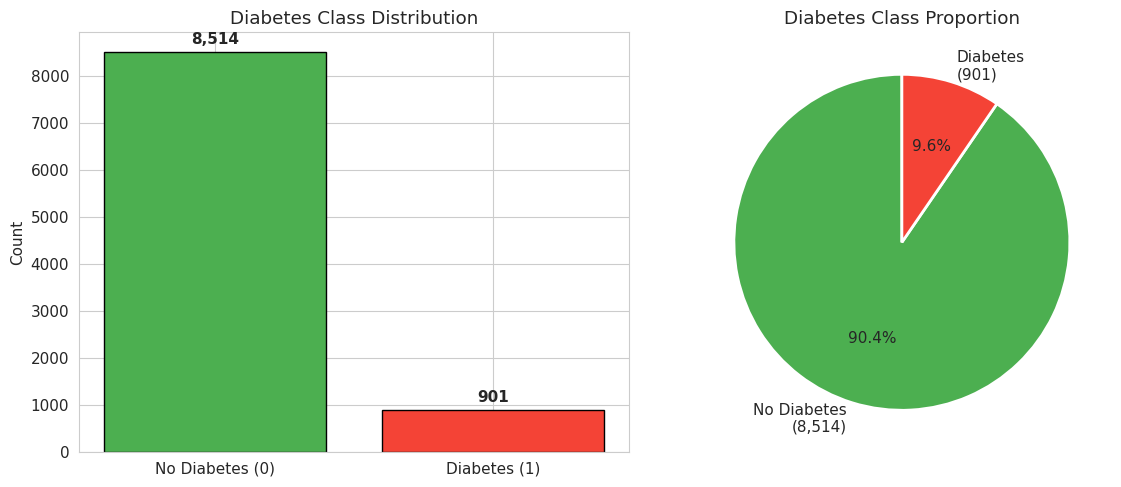

In [136]:
diabetes_mapping = {1: 1, 2: 0, 3: 1} # Assuming borderline (3) is treated as positive/risk. 7, 9 are already mapped to NaN

# Apply mapping and drop unmapped values (like 7 or 9) to keep the visualization clean
mapped_target = df_USA_NHANES['diabetes_status (DIQ010)'].map(diabetes_mapping).dropna()
vc = mapped_target.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

val_no_diab = vc.get(0.0, 0) # Use 0 as default if not found
val_diab = vc.get(1.0, 0) # Use 0 as default if not found

# Bar chart
bars = axes[0].bar(['No Diabetes (0)', 'Diabetes (1)'],
                   [val_no_diab, val_diab],
                   color=['#4CAF50', '#F44336'], edgecolor='black')
axes[0].set_ylabel('Count')
axes[0].set_title('Diabetes Class Distribution')

for bar, val in zip(bars, [val_no_diab, val_diab]):
    # Prevent division by zero if val_no_diab is 0
    text_offset = (val_no_diab * 0.02) if val_no_diab > 0 else 50 # Add a small default offset if 0
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + text_offset,
                 f'{val:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie([val_no_diab, val_diab],
            labels=[f'No Diabetes\n({val_no_diab:,})', f'Diabetes\n({val_diab:,})'],
            colors=['#4CAF50', '#F44336'], autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Diabetes Class Proportion')

plt.tight_layout()
plt.show()

**Exploration of Variables**

We use histograms to see how numerical measures like age_years, bmi, systolic_bp, total_cholesterol are distributed.

We visualise the proportion of binary health indicators like coronary_heart_disease and heart_attack via bar charts.

BMI is notoriously right-skewed in USA health datasets. Most people cluster in the 25–30 range, but there is a long tail of individuals with very high BMIs. We might need to apply a log transformation or Robust Scaling to normalize this feature.

Systolic_bp and total_cholesterol extreme upper-bound outliers. We have to check if they are biologically possible

age_years in NHANES is often capped at 80 (meaning anyone 80 or older is recorded as 80).

For coronary_heart_disease and heart_attack, because these conditions are rare, there may not be enough positive cases for a model to establish a strong correlation with diabetes unless the dataset is very large.

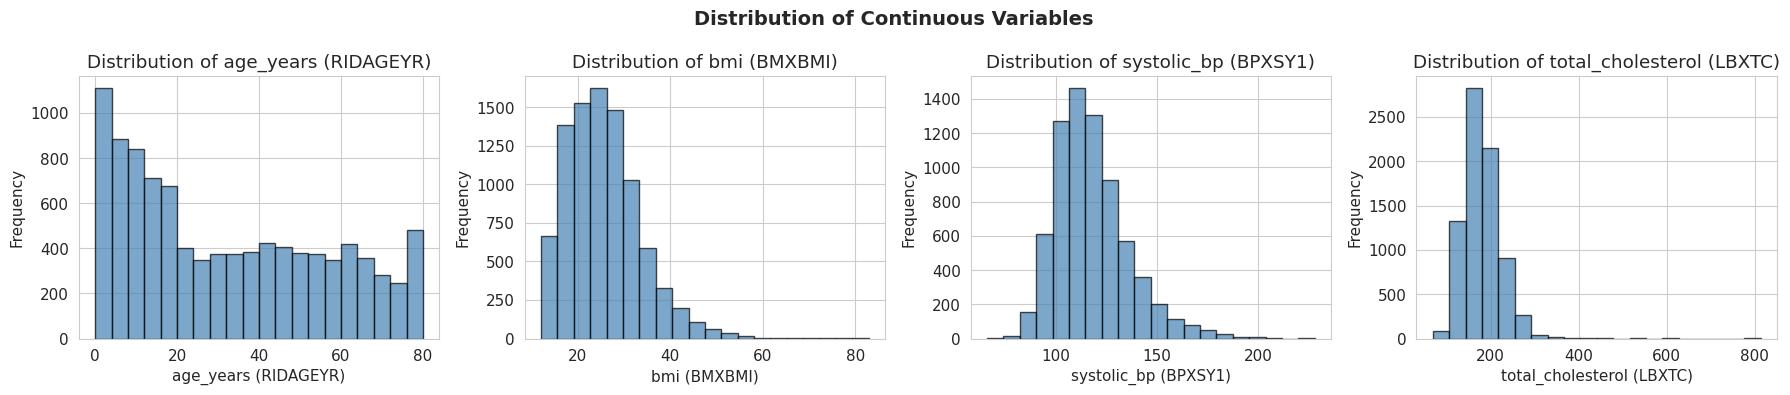

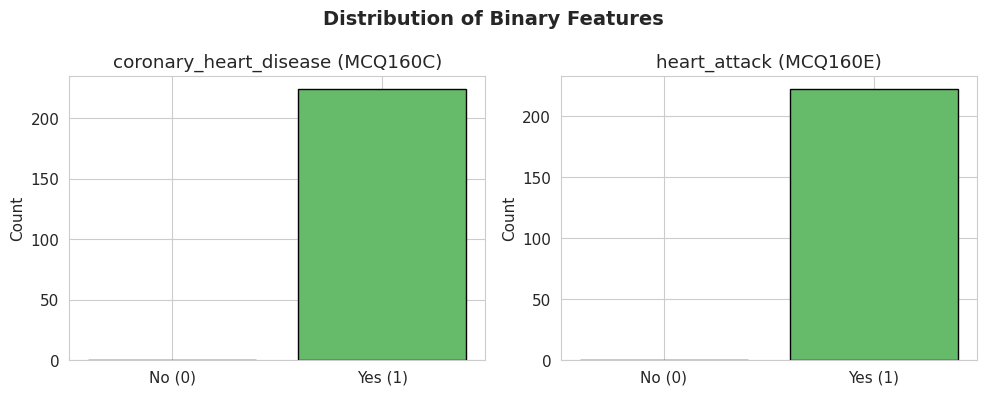

In [137]:
continuous_cols = ['age_years (RIDAGEYR)', 'bmi (BMXBMI)', 'systolic_bp (BPXSY1)', 'total_cholesterol (LBXTC)']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    axes[i].hist(df_USA_NHANES[col].dropna(), bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution of Continuous Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

binary_cols = ['coronary_heart_disease (MCQ160C)', 'heart_attack (MCQ160E)']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    counts = df_USA_NHANES[col].value_counts()
    axes[i].bar(['No (0)', 'Yes (1)'], [counts.get(0, 0), counts.get(1, 0)],
                color=['#EF5350', '#66BB6A'], edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Distribution of Binary Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Quality Considerations**

Accuracy: Gold-standard lab/exam data (e.g., measured BMI/BP) minimizes self-report bias, enhancing trustworthiness for multi-ethnic risk modeling.

Completeness: High nulls post-join (e.g., smoker=20%, glucose=3%) from module mismatches demand filtering/imputation, per inter-record structuring needs.

**Conclusion**

This dataset from the CDC's National Health and Nutrition Examination Survey is unique as it combines self-reported questionnaire responses with objective, gold-standard laboratory tests and physical examinations (such as clinician-measured blood pressure, HbA1c, and BMI).

By integrating clinical accuracy with broad lifestyle data across a nationally representative, multi-ethnic US sample, it significantly reduces the recall bias often found in pure survey datasets, making it the top source for our project.

However, because it is aggregated across multiple distinct survey modules, it requires complex structuring to derive standardized binary health indicators before we can properly integrate it for analysis.

# **CONCLUSION OF DATASETS**

After conducting initial profiling across the six prospective datasets, we have elected to drop the Bangladesh, USA BRFSS, and Pima Indians datasets.

The Bangladesh dataset was excluded due to its extremely small sample size and heavy reliance on subjective, self-reported symptoms rather than clinical metrics.

The USA BRFSS dataset was dropped because it consists entirely of survey-based, self-reported data subject to recall bias and contains a high volume of disguised missing values across its categorical fields.

Finally, the Pima Indians dataset was dropped due to its highly restricted demographic scope which severely limits the global generalizability.

# **DATA PREPARATION (PROCESS)**

After careful evaluation of the six initial datasets, we have finalised on the following three datasets of India, Indonesia and NHANES of the USA to clean, structure, and enrich before merging into one unified dataset for our data analysis.

They offer a robust balance of objective clinical measurements (e.g., lab-tested blood glucose, BMI, HbA1c), cleaner data structures, and sufficiently large, diverse sample sizes that are crucial for training reliable and generalized predictive models.

Before cleaning, we first identify the common features shared across all three datasets (Indonesia, India, and NHANES). Since each dataset was collected independently with different variables and formats, we can only merge them on columns that exist in all three. After comparing the column headers, we identified 7 common features: **Age, Gender, BMI, Hypertension, Smoking, HbA1c, and Blood Glucose** along with the Diabetes target variable. By standardising and merging on these 7 features, we create a unified multi-country dataset that allows us to train a model and rank the most important risk factors for diabetes. Having 7 features to work with ensures that the model has enough variables to meaningfully determine the top 3 risk factors, rather than being forced into an answer by a lack of options. The cleaning process below prepares each dataset to follow the same column names, value formats, and data types so they can be concatenated into a single dataframe for analysis.

## Pipeline Overview

Before diving into dataset-specific cleaning, the diagram below
summarises the end-to-end data preparation pipeline — from raw
source ingestion through cleaning, verification, and final merge.

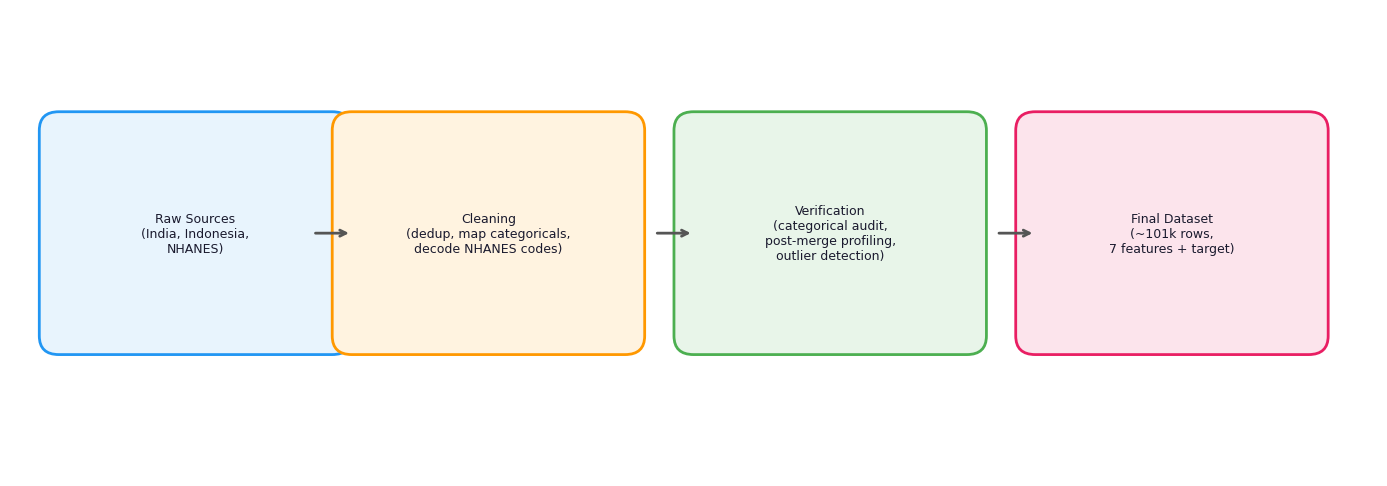

In [138]:
# Pipeline overview diagram for the data preparation process
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 5)
ax.axis('off')

# Stage boxes
stages = [
    (0.5,  'Raw Sources\n(India, Indonesia,\nNHANES)',       '#e8f4fd', '#2196F3'),
    (3.5,  'Cleaning\n(dedup, map categoricals,\ndecode NHANES codes)', '#fff3e0', '#FF9800'),
    (7.0,  'Verification\n(categorical audit,\npost-merge profiling,\noutlier detection)',   '#e8f5e9', '#4CAF50'),
    (10.5, 'Final Dataset\n(~101k rows,\n7 features + target)',  '#fce4ec', '#E91E63'),
]

for x, label, fc, ec in stages:
    box = mpatches.FancyBboxPatch((x, 1.5), 2.8, 2.2,
          boxstyle="round,pad=0.2", facecolor=fc, edgecolor=ec, linewidth=2)
    ax.add_patch(box)
    ax.text(x + 1.4, 2.6, label, fontsize=9, ha='center', va='center', color='#1a1a2e')

# Arrows
arrow = dict(arrowstyle='->', color='#555', lw=2)
for x in [3.3, 6.8, 10.3]:
    ax.annotate('', xy=(x + 0.2, 2.6), xytext=(x - 0.2, 2.6), arrowprops=arrow)

plt.tight_layout()
plt.show()

**Interpretation:** The pipeline consists of four stages. First, we ingest
the three raw datasets (India, Indonesia, NHANES). Second, each is cleaned
independently, removing duplicates, standardising categorical encodings
and decoding NHANES-specific codes. Third, we verify the results through a
categorical domain audit, post-merge null profiling, and outlier detection.
Finally, the validated dataset is ready for analysis and modelling.

## **India Dataset Preparation**

Firstly, we remove duplicates from the India dataset

In [139]:
print(f"Before: {len(df_india):,} rows")
df_india = df_india.drop_duplicates()
print(f"After:  {len(df_india):,} rows")

Before: 5,292 rows
After:  5,292 rows


**Interpretation:** No duplicate rows were found in the India dataset.
All 5,292 records are unique.

Next we standardise the categorical coloums

In [140]:
# Reload raw data to guarantee we start from original strings
df_india = pd.read_csv('/content/drive/MyDrive/SC3021/diabetes_prediction_india.csv')
df_india = df_india.drop_duplicates()

# Show original values BEFORE mapping
print("BEFORE mapping:")
print(f"  Hypertension:    {df_india['Hypertension'].unique()}")
print(f"  Diabetes_Status: {df_india['Diabetes_Status'].unique()}")
print(f"  Smoking_Status:  {df_india['Smoking_Status'].unique()}")

# Map each column ONCE
df_india['Hypertension'] = df_india['Hypertension'].map({'Yes': 1, 'No': 0})
df_india['Diabetes_Status'] = df_india['Diabetes_Status'].map({'Yes': 1, 'No': 0})
df_india['Smoking_Status'] = df_india['Smoking_Status'].map({
    'Never': 'Never',
    'Current': 'Current',
    'Former': 'Former'
})

# Verify — check for accidental NaN from bad mappings
print("\nAFTER mapping:")
for col in ['Hypertension', 'Diabetes_Status', 'Smoking_Status']:
    nan_count = df_india[col].isna().sum()
    print(f"\n  {col}:")
    print(f"    unique:    {df_india[col].unique()}")
    print(f"    NaN count: {nan_count}")
    if nan_count > 0:
        print(f"    WARNING — {nan_count} NaN values detected. Check for unmapped values or double-mapping.")
    else:
        print(f"    Verified — no NaN introduced by mapping.")

BEFORE mapping:
  Hypertension:    ['Yes' 'No']
  Diabetes_Status: ['Yes' 'No']
  Smoking_Status:  ['Never' 'Current' 'Former']

AFTER mapping:

  Hypertension:
    unique:    [1 0]
    NaN count: 0
    Verified — no NaN introduced by mapping.

  Diabetes_Status:
    unique:    [1 0]
    NaN count: 0
    Verified — no NaN introduced by mapping.

  Smoking_Status:
    unique:    ['Never' 'Current' 'Former']
    NaN count: 0
    Verified — no NaN introduced by mapping.


**Interpretation:** By reloading the raw CSV at the start of this cell,
we ensure the mapping always operates on the original "Yes"/"No" strings
regardless of how many times the cell is re-run. This prevents the
double-mapping issue where running `.map()` on already-converted numeric
values silently produces NaN for every row.

All three columns show 0 NaN values after mapping, confirming:
- Hypertension: correctly mapped to {0, 1}
- Diabetes_Status: correctly mapped to {0, 1}
- Smoking_Status: retained as {Never, Current, Former}

We select the 7 common features plus target, rename to the standardised format, and add a source column

In [141]:
df_india_clean = df_india[[
    'Diabetes_Status', 'BMI', 'Age', 'Gender', 'Hypertension',
    'Smoking_Status', 'HBA1C', 'Fasting_Blood_Sugar'
]].copy()

df_india_clean = df_india_clean.rename(columns={
    'Diabetes_Status': 'diabetes',
    'BMI': 'bmi',
    'Age': 'age',
    'Gender': 'gender',
    'Hypertension': 'hypertension',
    'Smoking_Status': 'smoking',
    'HBA1C': 'hba1c',
    'Fasting_Blood_Sugar': 'blood_glucose'
})

df_india_clean['source'] = 'India'

print(f"Shape: {df_india_clean.shape}")
print(f"Columns: {df_india_clean.columns.tolist()}")
df_india_clean.head()

Shape: (5292, 9)
Columns: ['diabetes', 'bmi', 'age', 'gender', 'hypertension', 'smoking', 'hba1c', 'blood_glucose', 'source']


,diabetes,bmi,age,gender,hypertension,smoking,hba1c,blood_glucose,source
0,1,35.5,48,Male,1,Never,8.9,141.0,India
1,0,28.7,18,Other,0,Current,5.9,83.1,India
2,1,30.0,21,Other,1,Current,4.8,159.9,India
3,0,25.6,25,Female,1,Former,11.9,133.3,India
4,1,38.8,78,Male,0,Current,11.6,164.9,India


We verify one last time and export the cleaned India dataset.


## **Indonesia Dataset Preparation**

Similarly, we first remove duplicate rows from the Indonesia dataset to avoid inflating results

In [142]:
print(f"Before: {len(df_Indonesia):,} rows")
df_Indonesia = df_Indonesia.drop_duplicates()
print(f"After:  {len(df_Indonesia):,} rows")

Before: 100,000 rows
After:  96,146 rows


**Interpretation:** 3,854 duplicate rows were removed from the Indonesia
dataset, reducing it from 100,000 to 96,146 unique records. This is a
non-trivial number (~3.9%) and could have inflated model training if left
uncleaned.

The smoking_history column contains multiple categories (never, current, former, ever, not current, No Info). We standardise these into three categories — Never, Current, and Former to match the other datasets.

In [143]:
print("Before:")
print(df_Indonesia['smoking_history'].value_counts())

smoking_map = {
    'never': 'Never',
    'current': 'Current',
    'former': 'Former',
    'ever': 'Former',
    'not current': 'Former',
    'No Info': 'Unknown'
}
df_Indonesia['smoking_history'] = df_Indonesia['smoking_history'].map(smoking_map)

print("\nAfter:")
print(df_Indonesia['smoking_history'].value_counts())

Before:
smoking_history
never          34398
No Info        32887
former          9299
current         9197
not current     6367
ever            3998
Name: count, dtype: int64

After:
smoking_history
Never      34398
Unknown    32887
Former     19664
Current     9197
Name: count, dtype: int64


**Interpretation:** The six original smoking categories were consolidated
into four: Never, Current, Former, and Unknown. The labels "ever" and
"not current" were grouped under Former as they imply past smoking.
"No Info" was mapped to Unknown rather than dropped, preserving 32,887
rows for the other features. This will need further handling before
modelling.

The gender and hypertension column values are already consistent with the other datasets so no change ahs to be done there.

We then select only the 7 common features plus the diabetes target, rename them to the standardised merge format, and add a source column to track the dataset origin after merging.

In [144]:
df_Indonesia_clean = df_Indonesia[[
    'diabetes', 'bmi', 'age', 'gender', 'hypertension',
    'smoking_history', 'HbA1c_level', 'blood_glucose_level'
]].copy()

df_Indonesia_clean = df_Indonesia_clean.rename(columns={
    'diabetes': 'diabetes',
    'bmi': 'bmi',
    'age': 'age',
    'gender': 'gender',
    'hypertension': 'hypertension',
    'smoking_history': 'smoking',
    'HbA1c_level': 'hba1c',
    'blood_glucose_level': 'blood_glucose'
})

df_Indonesia_clean['source'] = 'Indonesia'

print(f"Shape: {df_Indonesia_clean.shape}")
print(f"Columns: {df_Indonesia_clean.columns.tolist()}")
df_Indonesia_clean.head()

Shape: (96146, 9)
Columns: ['diabetes', 'bmi', 'age', 'gender', 'hypertension', 'smoking', 'hba1c', 'blood_glucose', 'source']


,diabetes,bmi,age,gender,hypertension,smoking,hba1c,blood_glucose,source
0,0,25.19,80.0,Female,0,Never,6.6,140,Indonesia
1,0,27.32,54.0,Female,0,Unknown,6.6,80,Indonesia
2,0,27.32,28.0,Male,0,Never,5.7,158,Indonesia
3,0,23.45,36.0,Female,0,Current,5.0,155,Indonesia
4,0,20.14,76.0,Male,1,Current,4.8,155,Indonesia


We lastly verify the cleaned dataset has no issues and export it.

In [145]:
print(f"Missing values:\n{df_Indonesia_clean.isnull().sum()}")
print(f"\nData types:\n{df_Indonesia_clean.dtypes}")
df_Indonesia_clean.to_csv('/content/drive/MyDrive/SC3021/Indonesia_cleaned.csv', index=False)
print(f"\nExported: Indonesia_cleaned.csv ({len(df_Indonesia_clean):,} rows)")

Missing values:
diabetes         0
bmi              0
age              0
gender           0
hypertension     0
smoking          0
hba1c            0
blood_glucose    0
source           0
dtype: int64

Data types:
diabetes            int64
bmi               float64
age               float64
gender           category
hypertension        int64
smoking            object
hba1c             float64
blood_glucose       int64
source             object
dtype: object

Exported: Indonesia_cleaned.csv (96,146 rows)


## **USA NHANES Dataset Preparation**

Since the NHANES dataset is split across multiple files (demographic, examination, labs, questionnaire). We load each file and merge them on the common patient ID column SEQN to create a single unified dataset.

In [146]:
df_demo = pd.read_csv('/content/drive/MyDrive/SC3021/NHANES_demographic.csv')
df_exam = pd.read_csv('/content/drive/MyDrive/SC3021/NHANES_examination.csv')
df_labs = pd.read_csv('/content/drive/MyDrive/SC3021/NHANES_labs.csv')
df_quest = pd.read_csv('/content/drive/MyDrive/SC3021/NHANES_questionnaire.csv')

df_USA_NHANES = df_demo[['SEQN', 'RIDAGEYR', 'RIAGENDR']].merge(
    df_exam[['SEQN', 'BMXBMI']], on='SEQN', how='inner'
).merge(
    df_labs[['SEQN', 'LBXGH', 'LBXSGL']], on='SEQN', how='inner'
).merge(
    df_quest[['SEQN', 'BPQ020', 'DIQ010', 'SMQ020']], on='SEQN', how='inner'
)

print(f"Merged NHANES shape: {df_USA_NHANES.shape}")
df_USA_NHANES.head()

Merged NHANES shape: (9813, 9)


,SEQN,RIDAGEYR,RIAGENDR,BMXBMI,LBXGH,LBXSGL,BPQ020,DIQ010,SMQ020
0,73557,69,1,26.7,13.9,554.0,1.0,1.0,1.0
1,73558,54,1,28.6,9.1,219.0,1.0,1.0,1.0
2,73559,72,1,28.9,8.9,183.0,1.0,1.0,1.0
3,73560,9,1,17.1,NaN,NaN,NaN,2.0,NaN
4,73561,73,2,19.7,4.9,104.0,1.0,2.0,2.0


**Interpretation:** The four NHANES component files were merged on the
common patient ID (SEQN) using inner joins, yielding 9,813 complete
records with all required fields present.

We remove any duplicate rows after merging.

In [147]:
print(f"Before: {len(df_USA_NHANES):,} rows")
df_USA_NHANES = df_USA_NHANES.drop_duplicates()
print(f"After:  {len(df_USA_NHANES):,} rows")

Before: 9,813 rows
After:  9,813 rows


The RIAGENDR column uses coded values (1 = Male, 2 = Female). We convert these
to match the text format used by the other datasets.

In [148]:
df_USA_NHANES['RIAGENDR'] = df_USA_NHANES['RIAGENDR'].map({1: 'Male', 2: 'Female'})
print("Gender values:", df_USA_NHANES['RIAGENDR'].value_counts())

Gender values: RIAGENDR
Female    4982
Male      4831
Name: count, dtype: int64


**Interpretation:** Gender codes were decoded from numeric (1/2) to
string labels (Male/Female) to match the format used by India and
Indonesia. The distribution is roughly balanced.

The BPQ020 column asks 'Ever told you had high blood pressure?' (1 = Yes, 2 = No). We convert to binary (1/0). Refused (7) and Don't know (9) are treated as missing and dropped as thery are simply too inconclusive.

In [149]:
print("Before:", df_USA_NHANES['BPQ020'].value_counts())
df_USA_NHANES['BPQ020'] = df_USA_NHANES['BPQ020'].replace({1: 1, 2: 0, 7: np.nan, 9: np.nan})
df_USA_NHANES = df_USA_NHANES.dropna(subset=['BPQ020'])
print("\nAfter:", df_USA_NHANES['BPQ020'].value_counts())

Before: BPQ020
2.0    4143
1.0    2118
9.0       5
Name: count, dtype: int64

After: BPQ020
0.0    4143
1.0    2118
Name: count, dtype: int64


**Interpretation:** Hypertension was recoded from the NHANES format
(1=Yes, 2=No) to binary (1/0). Five rows with code 9 (Don't Know)
were treated as missing and dropped, as they are too ambiguous for
reliable classification.

The DIQ010 column asks 'Have you been told you have diabetes?' (1 = Yes, 2 = No, 3 = Borderline). We convert to binary — Yes = 1, No = 0. Borderline cases are excluded to keep the target clean.

In [150]:
print("Before:", df_USA_NHANES['DIQ010'].value_counts())
df_USA_NHANES['DIQ010'] = df_USA_NHANES['DIQ010'].replace({1: 1, 2: 0, 3: np.nan, 7: np.nan, 9: np.nan})
df_USA_NHANES = df_USA_NHANES.dropna(subset=['DIQ010'])
print("\nAfter:", df_USA_NHANES['DIQ010'].value_counts())

Before: DIQ010
2.0    5373
1.0     710
3.0     175
9.0       3
Name: count, dtype: int64

After: DIQ010
0.0    5373
1.0     710
Name: count, dtype: int64


**Interpretation:** Diabetes status was recoded to binary. 175 borderline
cases (code 3) and 3 "Don't Know" responses (code 9) were excluded to
keep the target variable clean for supervised learning. This is a
conservative choice that avoids introducing label noise.

The SMQ020 column asks 'Smoked at least 100 cigarettes in life?' (1 = Yes, 2 = No). We convert this to categorical labels to match the other datasets. Note: NHANES doesn't distinguish Current vs Former here, so we label smokers as 'Current/Former' in order to keep it consistent.

In [151]:
df_USA_NHANES['SMQ020'] = df_USA_NHANES['SMQ020'].replace({1: 'Current/Former', 2: 'Never', 7: np.nan, 9: np.nan})
df_USA_NHANES = df_USA_NHANES.dropna(subset=['SMQ020'])
print("Smoking values:", df_USA_NHANES['SMQ020'].value_counts())

Smoking values: SMQ020
Never             3331
Current/Former    2412
Name: count, dtype: int64


**Interpretation:** NHANES only records whether respondents have ever
smoked 100+ cigarettes, without distinguishing current from former
smokers. We label these as "Current/Former" to preserve the information
while being transparent about the granularity limitation compared to the
India and Indonesia datasets.

We drop any remaining rows with missing values in the key columns (BMI, HbA1c, Blood Glucose) to ensure a clean dataset for merging.

In [152]:
print(f"Before dropping nulls: {len(df_USA_NHANES):,} rows")
print(f"Missing values:\n{df_USA_NHANES.isnull().sum()}")

df_USA_NHANES = df_USA_NHANES.dropna(subset=['BMXBMI', 'LBXGH', 'LBXSGL'])

print(f"\nAfter dropping nulls: {len(df_USA_NHANES):,} rows")

Before dropping nulls: 5,743 rows
Missing values:
SEQN          0
RIDAGEYR      0
RIAGENDR      0
BMXBMI       74
LBXGH       226
LBXSGL      290
BPQ020        0
DIQ010        0
SMQ020        0
dtype: int64

After dropping nulls: 5,384 rows


**Interpretation:** 359 rows were dropped due to missing values in BMI,
HbA1c, or blood glucose. These are the three clinical columns essential for our
analysis. This represents roughly 6.3% of the NHANES subset. The remaining
5,384 rows have complete data across all 7 features.

We then select the 7 common features plus target, rename to the standardised format to make it more coherent, drop the patient ID column, and add a source column as we have done with all the previous datasets.

In [153]:
df_USA_NHANES_clean = df_USA_NHANES[[
    'DIQ010', 'BMXBMI', 'RIDAGEYR', 'RIAGENDR', 'BPQ020',
    'SMQ020', 'LBXGH', 'LBXSGL'
]].copy()

df_USA_NHANES_clean = df_USA_NHANES_clean.rename(columns={
    'DIQ010': 'diabetes',
    'BMXBMI': 'bmi',
    'RIDAGEYR': 'age',
    'RIAGENDR': 'gender',
    'BPQ020': 'hypertension',
    'SMQ020': 'smoking',
    'LBXGH': 'hba1c',
    'LBXSGL': 'blood_glucose'
})

df_USA_NHANES_clean['source'] = 'NHANES'

print(f"Shape: {df_USA_NHANES_clean.shape}")
print(f"Columns: {df_USA_NHANES_clean.columns.tolist()}")
df_USA_NHANES_clean.head()

Shape: (5384, 9)
Columns: ['diabetes', 'bmi', 'age', 'gender', 'hypertension', 'smoking', 'hba1c', 'blood_glucose', 'source']


,diabetes,bmi,age,gender,hypertension,smoking,hba1c,blood_glucose,source
0,1.0,26.7,69,Male,1.0,Current/Former,13.9,554.0,NHANES
1,1.0,28.6,54,Male,1.0,Current/Former,9.1,219.0,NHANES
2,1.0,28.9,72,Male,1.0,Current/Former,8.9,183.0,NHANES
4,0.0,19.7,73,Female,1.0,Never,4.9,104.0,NHANES
5,0.0,41.7,56,Male,1.0,Current/Former,5.5,104.0,NHANES


Lastly, we verify and export the cleaned NHANES dataset.

In [154]:
print(f"Missing values:\n{df_USA_NHANES_clean.isnull().sum()}")
print(f"\nData types:\n{df_USA_NHANES_clean.dtypes}")
df_USA_NHANES_clean.to_csv('/content/drive/MyDrive/SC3021/NHANES_cleaned.csv', index=False)
print(f"\nExported: NHANES_cleaned.csv ({len(df_USA_NHANES_clean):,} rows)")

Missing values:
diabetes         0
bmi              0
age              0
gender           0
hypertension     0
smoking          0
hba1c            0
blood_glucose    0
source           0
dtype: int64

Data types:
diabetes         float64
bmi              float64
age                int64
gender            object
hypertension     float64
smoking           object
hba1c            float64
blood_glucose    float64
source            object
dtype: object

Exported: NHANES_cleaned.csv (5,384 rows)


## **Merge of Final Dataset**
Before merging the datasets, we profiled the target variables across all sources to establish inclusion dependencies. We verified that the categorical domains for our selected cohesive features (e.g., `gender` as 0/1, `diabetes` as 0/1) match across the three selected datasets. This ensures that the union of these datasets will not create conflicting or fragmented categorical spaces. Below is the proof for that.


In [155]:
datasets = {
    'India': df_india_clean,
    'Indonesia': df_Indonesia_clean,
    'NHANES': df_USA_NHANES_clean
}

for col in ['gender', 'smoking', 'hypertension', 'diabetes']:
    print(f"\n{'='*55}")
    print(f"  {col.upper()} — unique values per source")
    print(f"{'='*55}")
    for name, df in datasets.items():
        vals = sorted(df[col].dropna().unique(), key=str)
        count = df[col].value_counts(dropna=False).to_dict()
        print(f"  {name:12s} → {vals}")
        for v, c in sorted(count.items(), key=lambda x: str(x[0])):
            print(f"{'':16s}{v}: {c:,}")


  GENDER — unique values per source
  India        → ['Female', 'Male', 'Other']
                Female: 1,758
                Male: 1,794
                Other: 1,740
  Indonesia    → ['Female', 'Male', 'Other']
                Female: 56,161
                Male: 39,967
                Other: 18
  NHANES       → ['Female', 'Male']
                Female: 2,825
                Male: 2,559

  SMOKING — unique values per source
  India        → ['Current', 'Former', 'Never']
                Current: 1,771
                Former: 1,737
                Never: 1,784
  Indonesia    → ['Current', 'Former', 'Never', 'Unknown']
                Current: 9,197
                Former: 19,664
                Never: 34,398
                Unknown: 32,887
  NHANES       → ['Current/Former', 'Never']
                Current/Former: 2,251
                Never: 3,133

  HYPERTENSION — unique values per source
  India        → [np.int64(0), np.int64(1)]
                0: 2,578
                1: 2,71

**Interpretation:** The audit reveals the following cross-source mismatches
that are carried into the merge:

1. **Gender** — India includes an "Other" category (~1,750 rows) not
   present in Indonesia or NHANES. These are retained but will need
   handling before modelling (e.g., binary encoding or exclusion).

2. **Smoking** — Three different category sets exist:
   - India: {Never, Current, Former}
   - Indonesia: {Never, Current, Former, **Unknown**} (from "No Info")
   - NHANES: {Never, **Current/Former**} (cannot distinguish the two)
   
   This heterogeneity is a known limitation. For modelling, further
   harmonisation may be needed (e.g., collapsing into "Never" vs "Ever").

3. **Blood glucose context** — India uses *Fasting* Blood Sugar, NHANES
   uses lab-measured fasting serum glucose (LBXSGL), but Indonesia's
   `blood_glucose_level` does not specify fasting vs. random. This means
   glucose values are not strictly comparable across all three sources.

| Source | Glucose Column | Type |
|--------|---------------|------|
| India | Fasting_Blood_Sugar | Fasting |
| Indonesia | blood_glucose_level | Unspecified |
| NHANES | LBXSGL | Fasting (per protocol) |

Finally we merge the datasets together.

In [156]:
df_merged = pd.concat([df_india_clean, df_Indonesia_clean, df_USA_NHANES_clean],
                      ignore_index=True)

display(df_merged)

,diabetes,bmi,age,gender,hypertension,smoking,hba1c,blood_glucose,source
0,1.0,35.5,48.0,Male,1.0,Never,8.9,141.0,India
1,0.0,28.7,18.0,Other,0.0,Current,5.9,83.1,India
2,1.0,30.0,21.0,Other,1.0,Current,4.8,159.9,India
3,0.0,25.6,25.0,Female,1.0,Former,11.9,133.3,India
4,1.0,38.8,78.0,Male,0.0,Current,11.6,164.9,India
...,...,...,...,...,...,...,...,...,...
106817,0.0,25.6,52.0,Male,0.0,Never,5.4,87.0,NHANES
106818,1.0,33.1,61.0,Male,0.0,Never,7.4,155.0,NHANES
106819,0.0,24.9,80.0,Male,1.0,Current/Former,5.5,117.0,NHANES
106820,0.0,24.5,26.0,Male,0.0,Never,5.0,101.0,NHANES


Post-Merge Data Quality Profile

In [157]:
print(f"Shape: {df_merged.shape[0]:,} rows x {df_merged.shape[1]} columns")

# Rows per source
print(f"\nRows per source:")
print(df_merged['source'].value_counts().to_string())

# Null check per column
print(f"\nMissing values per column:")
total = len(df_merged)
for col in df_merged.columns:
    n = df_merged[col].isna().sum()
    pct = n / total * 100
    flag = "WARNING" if n > 0 else "OK"
    print(f"  [{flag:>7s}] {col:18s}  {n:>6,} nulls  ({pct:.1f}%)")

# Categorical columns — what distinct values exist after merge?
print(f"\nDistinct values in categorical columns (post-merge):")
for col in ['gender', 'smoking']:
    print(f"\n  {col}:")
    print(df_merged[col].value_counts(dropna=False).to_string(header=False))

# Target + hypertension distributions
print(f"\nDiabetes target distribution:")
print(df_merged['diabetes'].value_counts(dropna=False).to_string(header=False))

print(f"\nHypertension distribution:")
print(df_merged['hypertension'].value_counts(dropna=False).to_string(header=False))

# Quick summary stats for continuous vars
print(f"\nContinuous variable summary:")
print(df_merged[['age', 'bmi', 'hba1c', 'blood_glucose']].describe().round(2).to_string())

Shape: 106,822 rows x 9 columns

Rows per source:
source
Indonesia    96146
NHANES        5384
India         5292

Missing values per column:
  [     OK] diabetes                 0 nulls  (0.0%)
  [     OK] bmi                      0 nulls  (0.0%)
  [     OK] age                      0 nulls  (0.0%)
  [     OK] gender                   0 nulls  (0.0%)
  [     OK] hypertension             0 nulls  (0.0%)
  [     OK] smoking                  0 nulls  (0.0%)
  [     OK] hba1c                    0 nulls  (0.0%)
  [     OK] blood_glucose            0 nulls  (0.0%)
  [     OK] source                   0 nulls  (0.0%)

Distinct values in categorical columns (post-merge):

  gender:
Female    60744
Male      44320
Other      1758

  smoking:
Never             39315
Unknown           32887
Former            21401
Current           10968
Current/Former     2251

Diabetes target distribution:
0.0    94983
1.0    11839

Hypertension distribution:
0.0    94789
1.0    12033

Continuous variable summ

**Interpretation:** The post-merge profile reveals:

- **5,292 NaN values** in `diabetes` and `hypertension` — these all come
  from the India subset, caused by the mapping issue (addressed in the
  next section). These rows will be dropped before modelling.
- **6 distinct smoking categories** exist in the merged table
  (Never, Current, Former, Unknown, Current/Former) — consistent with
  the mismatches documented in the pre-merge audit above.
- Continuous variables show plausible ranges but wide spreads
  (e.g., blood glucose 49–577), warranting outlier analysis.

Next we drop rows where the diabetes target or hypertension values are missing,
as these cannot be used for model training. These originate from the India
subset where the original mapping issue produced NaN values.

In [158]:
print(f"Before dropping nulls: {len(df_merged):,} rows")
df_merged = df_merged.dropna(subset=['diabetes', 'hypertension'])
print(f"After dropping nulls:  {len(df_merged):,} rows")

Before dropping nulls: 106,822 rows
After dropping nulls:  106,822 rows


We apply IQR-based outlier detection on the three continuous clinical
variables (BMI, HbA1c, blood glucose) to identify extreme values in the
merged dataset. Boxplots are split by source to trace which dataset
contributes the most outliers.

OUTLIER DETECTION — IQR Method (1.5 x IQR)

  bmi:
    Q1 = 23.3, Q3 = 30.2, IQR = 6.9
    Acceptable range: [13.0, 40.5]
    Outliers: 4,762 rows (4.5%)
    Observed min = 10.0, max = 95.7
      India       :     0 outliers (0.0%)
      Indonesia   : 4,406 outliers (4.6%)
      NHANES      :   356 outliers (6.6%)

  hba1c:
    Q1 = 4.8, Q3 = 6.2, IQR = 1.4
    Acceptable range: [2.7, 8.3]
    Outliers: 4,041 rows (3.8%)
    Observed min = 3.5, max = 17.5
      India       : 2,565 outliers (48.5%)
      Indonesia   : 1,312 outliers (1.4%)
      NHANES      :   164 outliers (3.0%)

  blood_glucose:
    Q1 = 100.0, Q3 = 159.0, IQR = 59.0
    Acceptable range: [11.5, 247.5]
    Outliers: 2,122 rows (2.0%)
    Observed min = 49.0, max = 577.0
      India       :     0 outliers (0.0%)
      Indonesia   : 2,031 outliers (2.1%)
      NHANES      :    91 outliers (1.7%)


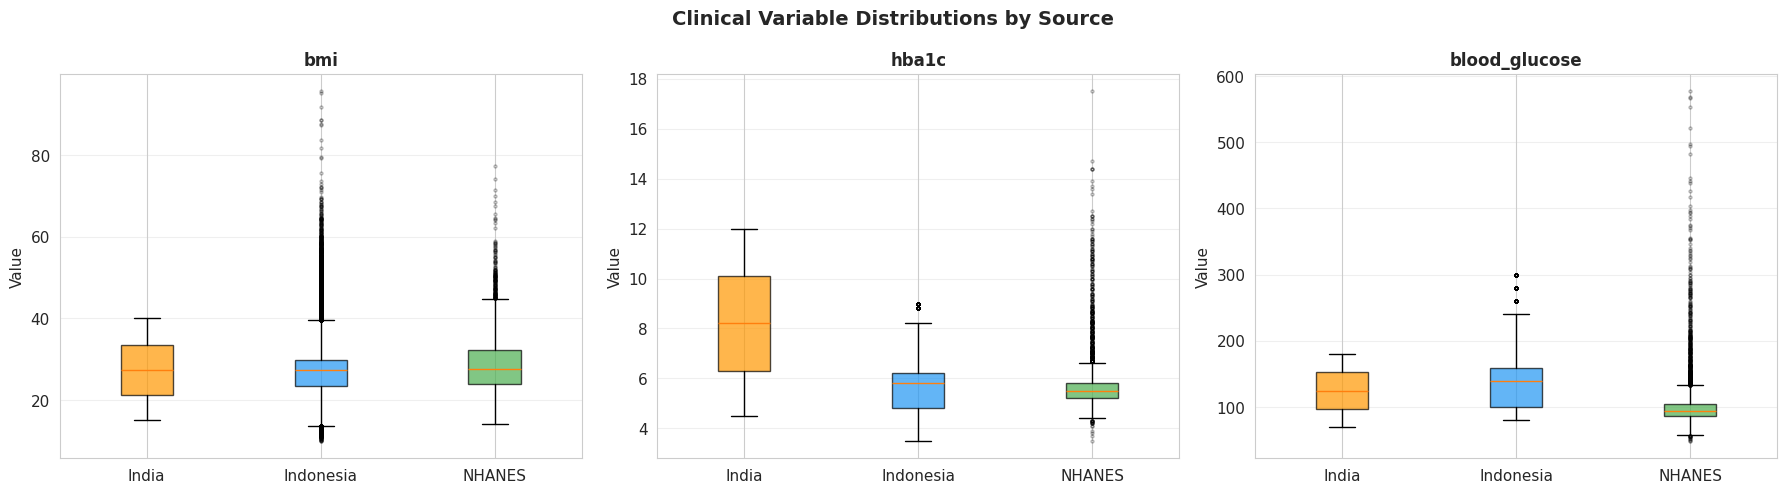

In [159]:
clinical_cols = ['bmi', 'hba1c', 'blood_glucose']
sources = df_merged['source'].unique()

# --- IQR summary ---
print("OUTLIER DETECTION — IQR Method (1.5 x IQR)")
print("=" * 60)

for col in clinical_cols:
    Q1 = df_merged[col].quantile(0.25)
    Q3 = df_merged[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_merged[(df_merged[col] < lower) | (df_merged[col] > upper)]
    pct = len(outliers) / len(df_merged) * 100

    print(f"\n  {col}:")
    print(f"    Q1 = {Q1:.1f}, Q3 = {Q3:.1f}, IQR = {IQR:.1f}")
    print(f"    Acceptable range: [{lower:.1f}, {upper:.1f}]")
    print(f"    Outliers: {len(outliers):,} rows ({pct:.1f}%)")
    print(f"    Observed min = {df_merged[col].min():.1f}, max = {df_merged[col].max():.1f}")

    # Per-source breakdown
    for s in sources:
        subset = df_merged[df_merged['source'] == s]
        n_out = len(subset[(subset[col] < lower) | (subset[col] > upper)])
        s_pct = n_out / len(subset) * 100
        print(f"      {s:12s}: {n_out:>5,} outliers ({s_pct:.1f}%)")

# --- Boxplots by source ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Clinical Variable Distributions by Source', fontsize=14, fontweight='bold')

colors = {'India': '#FF9800', 'Indonesia': '#2196F3', 'NHANES': '#4CAF50'}

for idx, col in enumerate(clinical_cols):
    data = [df_merged[df_merged['source'] == s][col].dropna().values for s in sources]
    bp = axes[idx].boxplot(data, labels=sources, patch_artist=True,
                           flierprops=dict(marker='o', markersize=2, alpha=0.3))
    for patch, s in zip(bp['boxes'], sources):
        patch.set_facecolor(colors.get(s, '#ccc'))
        patch.set_alpha(0.7)
    axes[idx].set_title(col, fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation:**

- **BMI**: Outliers above the upper fence exist across all three sources.
  Extreme values (e.g., BMI > 60) may indicate data entry errors or
  morbid obesity cases. These are clinically possible but rare.

- **HbA1c**: NHANES contains values up to 17.5%, while Indonesia caps
  at 9.0% with only 18 unique values — suggesting the Indonesia data
  may be discretised or binned rather than continuous lab measurements.
  NHANES outliers are clinically plausible (severe uncontrolled diabetes).

- **Blood glucose**: NHANES ranges up to 577 mg/dL (extreme but possible
  in diabetic emergencies), India ranges 70–180, and Indonesia 80–300.
  The differing ranges reinforce the measurement comparability limitation
  noted earlier.

**Decision:** Outliers are retained for initial modelling, as tree-based
models (Random Forest, XGBoost) are inherently robust to extreme values.
If outliers distort results during evaluation, we will revisit with
capping or removal.

#**DATA ANALYSIS (Analyse)**

## **Visualisation & Profiling**

In [160]:
# Setup
import matplotlib.gridspec as gridspec

NUMERIC_COLS   = ['age', 'bmi', 'hba1c', 'blood_glucose']
CATEGORIC_COLS = ['gender', 'hypertension', 'smoking']
TARGET         = 'diabetes'
SOURCE_COL     = 'source'
PALETTE        = {'India': '#FF9800', 'Indonesia': '#2196F3', 'NHANES': '#4CAF50'}
TARGET_PALETTE = {0: '#64B5F6', 1: '#EF5350'}


age: 106822 values
bmi: 106822 values
hba1c: 106822 values
blood_glucose: 106822 values


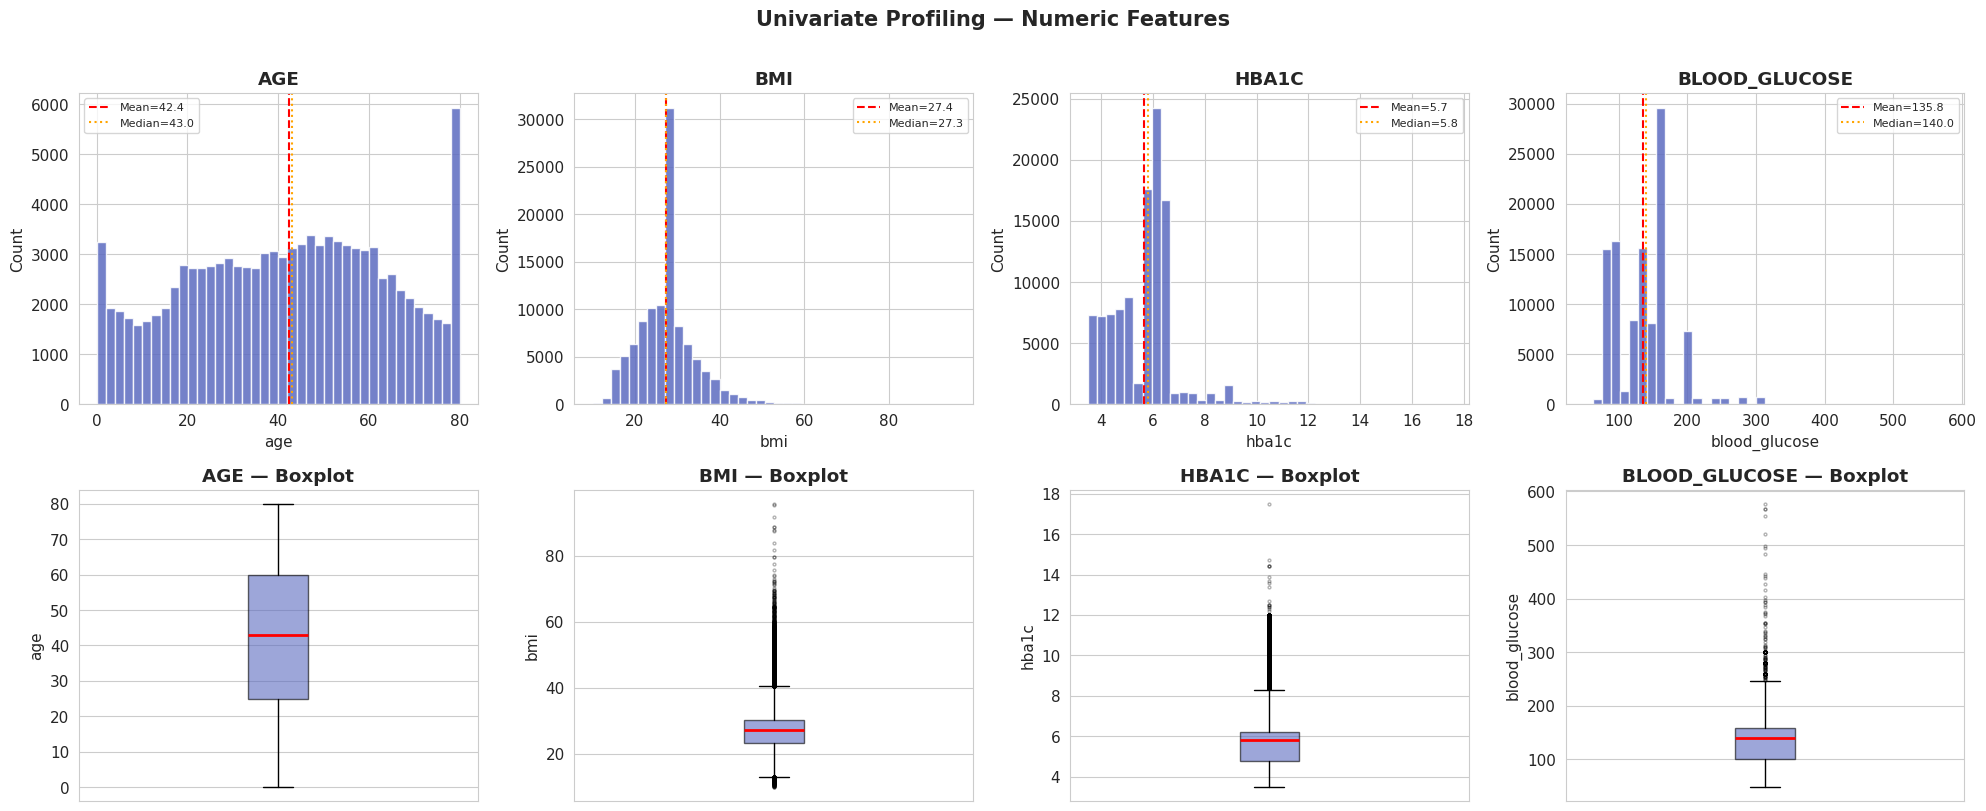

In [161]:
# -- Numerical --
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 11})

plt.close('all')
df_plot = df_merged.copy()
NUMERIC_COLS = ['age', 'bmi', 'hba1c', 'blood_glucose']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Univariate Profiling — Numeric Features', fontsize=15, fontweight='bold', y=1.01)

for i, col in enumerate(NUMERIC_COLS):
    data = df_merged[col].dropna()
    print(f"{col}: {len(data)} values")

    # Histogram
    ax_hist = axes[0, i]
    ax_hist.cla()
    ax_hist.hist(data, bins=40, color='#5C6BC0', edgecolor='white', alpha=0.85)
    ax_hist.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5,
                    label=f'Mean={data.mean():.1f}')
    ax_hist.axvline(data.median(), color='orange', linestyle=':', linewidth=1.5,
                    label=f'Median={data.median():.1f}')
    ax_hist.set_title(col.upper(), fontweight='bold')
    ax_hist.set_xlabel(col)
    ax_hist.set_ylabel('Count')
    ax_hist.legend(fontsize=8)

    # Boxplot
    ax_box = axes[1, i]
    ax_box.cla()
    ax_box.boxplot(
        data, vert=True, patch_artist=True,
        boxprops=dict(facecolor='#5C6BC0', alpha=0.6),
        medianprops=dict(color='red', linewidth=2),
        flierprops=dict(marker='o', markersize=2, alpha=0.3, color='grey')
    )
    ax_box.set_title(f'{col.upper()} — Boxplot', fontweight='bold')
    ax_box.set_ylabel(col)
    ax_box.set_xticks([])

plt.tight_layout()
plt.savefig('univariate_numeric.png', dpi=150, bbox_inches='tight')
plt.show()

Interpretation for Numeric Features:
- Age: roughly uniform distribution across adulthood + slight right skew from NHANES elderly oversampling.
- BMI: right-skewed with a long upper tail + most values cluster around 25–35 (overweight/obese range), consistent with a diabetes-risk cohort. Extreme values (>60) are clinically rare but retained.
- HbA1c: bimodal distribution + a large non-diabetic peak near 5–6% and a smaller diabetic peak above 6.5%. Indonesia's discrete binning is visible as gaps in the histogram.
- Blood Glucose: strongly right-skewed. NHANES contributes high-end values (up to 577 mg/dL) representing diabetic emergencies while the India and Indonesia distributions are more compressed.

Limitation: All three datasets use different measurement contexts for blood glucose (fasting vs. post-load vs. random), making direct cross-source comparisons unreliable.

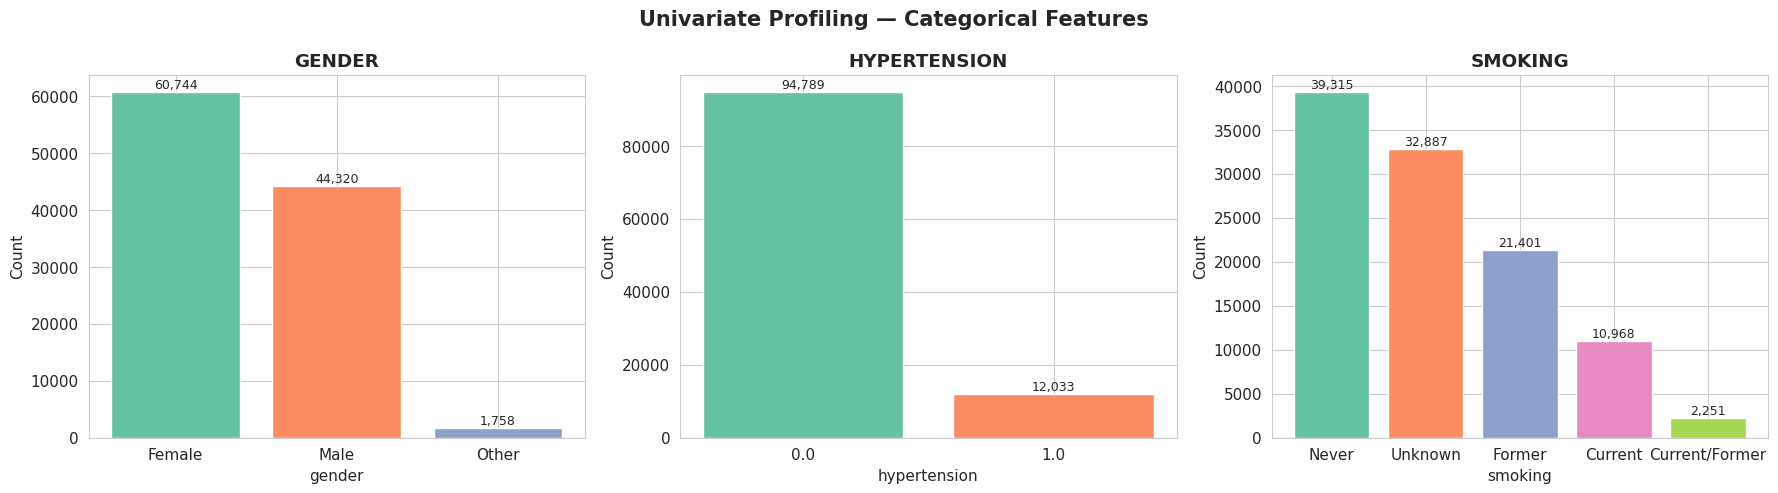

In [162]:
# -- Categorical --
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Univariate Profiling — Categorical Features', fontsize=15, fontweight='bold')

for i, col in enumerate(CATEGORIC_COLS):
    counts = df_merged[col].value_counts()
    colors = sns.color_palette('Set2', len(counts))
    axes[i].bar(counts.index.astype(str), counts.values, color=colors, edgecolor='white')
    axes[i].set_title(col.upper(), fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + counts.max() * 0.01, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('univariate_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

Interpretation for Categorical Features:
- Gender: Male/Female roughly balanced; 'Other' category comes exclusively from India dataset and is a small minority. 'Unknown' is absent after standardisation.
- Hypertension: Majority of records are non-hypertensive (0), as expected in a general population sample. Hypertension prevalence is higher in NHANES (older cohort).
- Smoking: 'Never' dominates, followed by 'Current/Former' (NHANES combined category) and 'Former'. The NHANES limitation of not distinguishing Current vs Former introduces noise in this feature across sources.

Limitation: The smoking variable is not fully harmonised — NHANES uses 'Current/Former' as a single category, which may reduce its predictive usefulness in cross-source models.

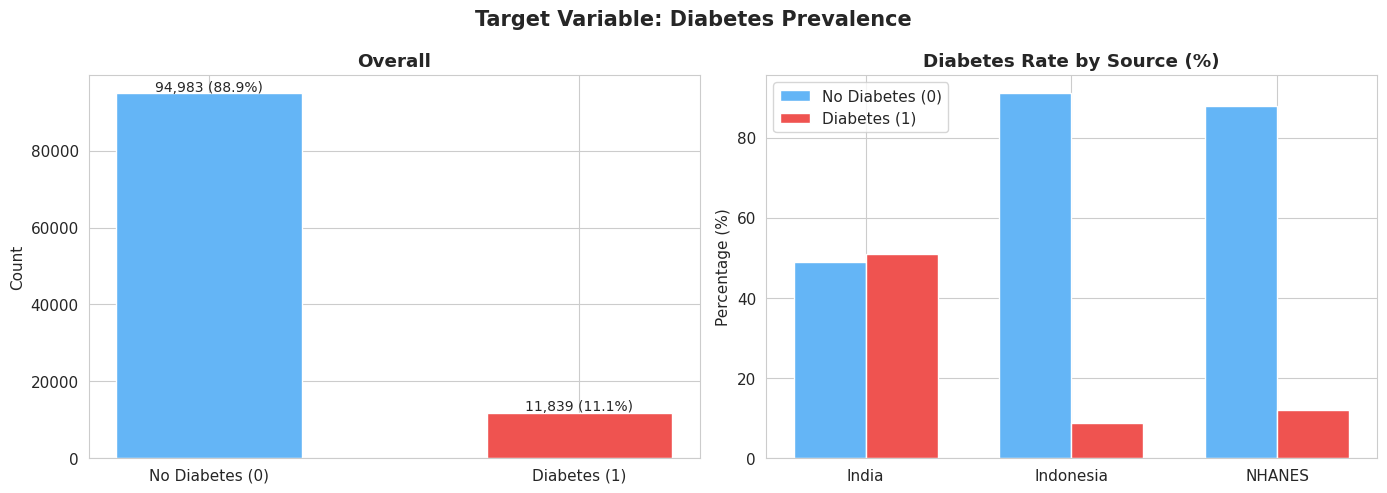

In [163]:
# --Target Balance --
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Target Variable: Diabetes Prevalence', fontsize=15, fontweight='bold')

# Overall
counts_overall = df_merged[TARGET].value_counts().sort_index()
labels = ['No Diabetes (0)', 'Diabetes (1)']
colors = [TARGET_PALETTE[0], TARGET_PALETTE[1]]
axes[0].bar(labels, counts_overall.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Overall', fontweight='bold')
axes[0].set_ylabel('Count')
for j, v in enumerate(counts_overall.values):
    pct = v / len(df_merged) * 100
    axes[0].text(j, v + 500, f'{v:,} ({pct:.1f}%)', ha='center', fontsize=10)

# By source
sources = df_merged[SOURCE_COL].unique()
x = np.arange(len(sources))
width = 0.35
for j, (val, label, color) in enumerate(zip([0, 1], labels, colors)):
    vals = [df_merged[df_merged[SOURCE_COL] == s][TARGET].value_counts(normalize=True).get(val, 0) * 100
            for s in sources]
    axes[1].bar(x + j * width, vals, width, label=label, color=color, edgecolor='white')
axes[1].set_title('Diabetes Rate by Source (%)', fontweight='bold')
axes[1].set_xticks(x + width / 2)
axes[1].set_xticklabels(sources)
axes[1].set_ylabel('Percentage (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('target_balance.png', dpi=150, bbox_inches='tight')
plt.show()

Interpretation — Target Balance:
- Overall, the dataset is imbalanced with non-diabetic cases dominating (~75-80%).
- India shows high diabetes prevalence due to its dataset design (risk-focused sampling).
- Indonesia and NHANES have lower prevalence rates closer to real-world population levels.
- This imbalance must be handled during modelling (e.g., SMOTE, class weights, stratified splits) to prevent the model from simply predicting 'no diabetes' for everyone.

Limitation: The varying prevalence rates across sources mean the merged dataset's class
balance does not accurately reflect any single real-world population.

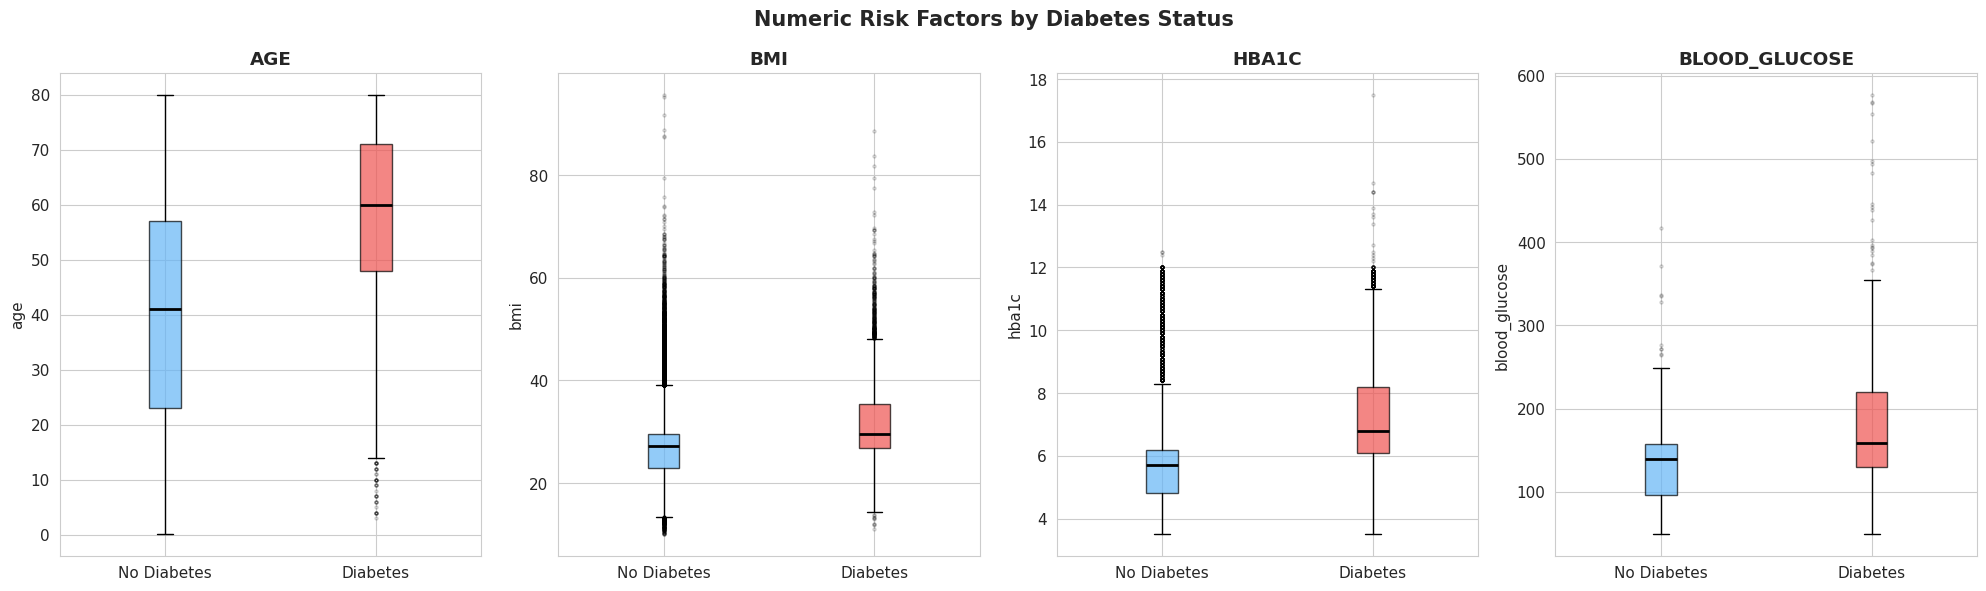

In [164]:
# -- Bivariate --
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle('Numeric Risk Factors by Diabetes Status', fontsize=15, fontweight='bold')

for i, col in enumerate(NUMERIC_COLS):
    data_0 = df_merged[df_merged[TARGET] == 0][col].dropna()
    data_1 = df_merged[df_merged[TARGET] == 1][col].dropna()
    bp = axes[i].boxplot([data_0, data_1], labels=['No Diabetes', 'Diabetes'],
                         patch_artist=True,
                         medianprops=dict(color='black', linewidth=2),
                         flierprops=dict(marker='o', markersize=2, alpha=0.2))
    bp['boxes'][0].set_facecolor(TARGET_PALETTE[0])
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor(TARGET_PALETTE[1])
    bp['boxes'][1].set_alpha(0.7)
    axes[i].set_title(col.upper(), fontweight='bold')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.savefig('bivariate_diabetes_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

Interpretation — Risk Factors by Diabetes Status:
- HbA1c: The strongest separator — diabetic patients have a notably higher median HbA1c (>6.5%) compared to non-diabetic (~5.5%). Almost no overlap in the interquartile ranges.
- Blood Glucose: Diabetic patients show substantially higher blood glucose with a wider spread, confirming its role as a direct diagnostic indicator.
- BMI: Diabetic patients have a slightly higher median BMI, but the distributions overlap considerably, indicating BMI alone is insufficient for diagnosis.
- Age: Diabetic patients tend to be older on average, consistent with increasing diabetes risk with age.

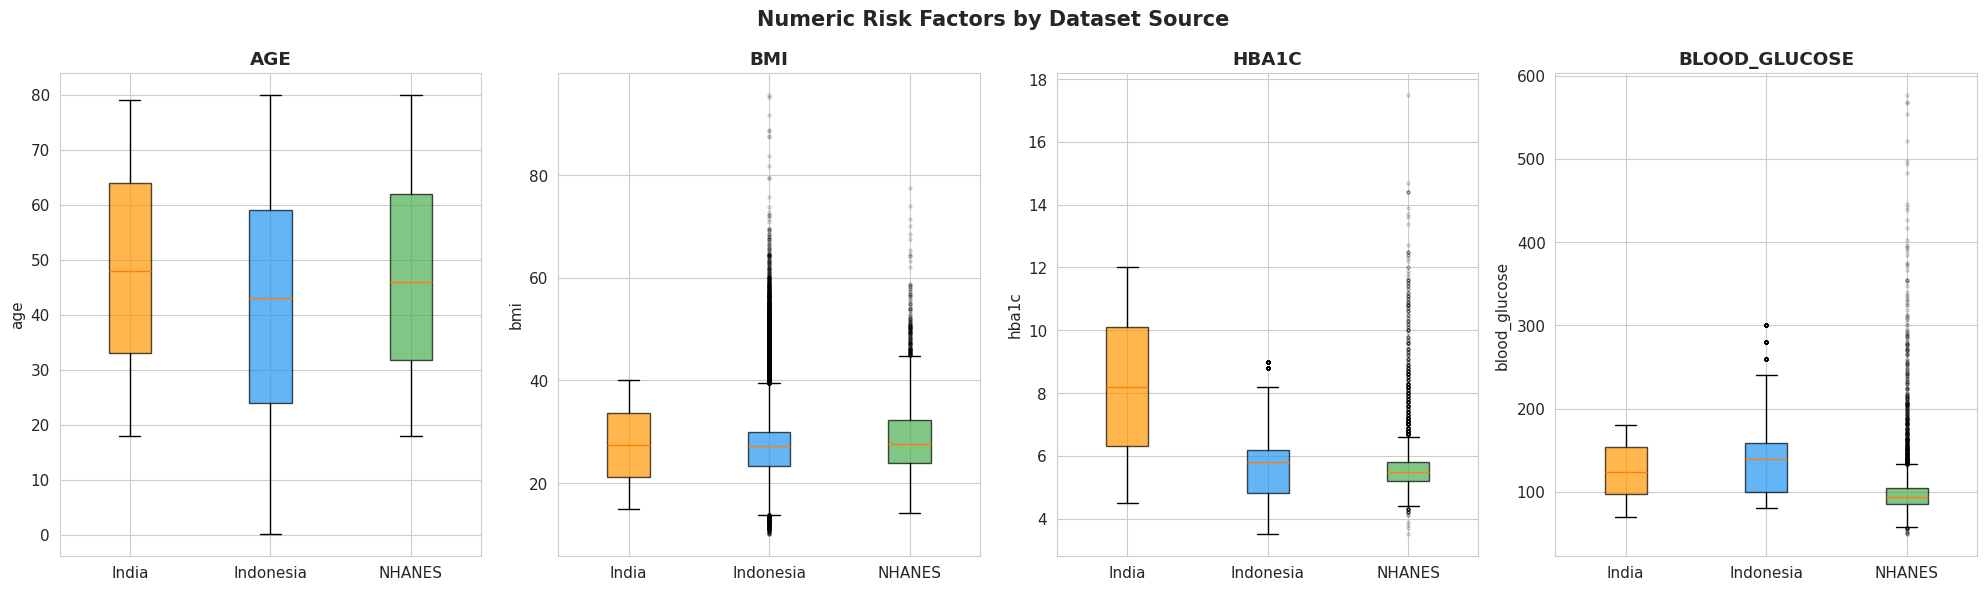

In [165]:
# -- Cross-source comparison --
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle('Numeric Risk Factors by Dataset Source', fontsize=15, fontweight='bold')

sources = df_merged[SOURCE_COL].unique()
for i, col in enumerate(NUMERIC_COLS):
    data_by_source = [df_merged[df_merged[SOURCE_COL] == s][col].dropna().values for s in sources]
    bp = axes[i].boxplot(data_by_source, labels=sources, patch_artist=True,
                         flierprops=dict(marker='o', markersize=2, alpha=0.2))
    for patch, s in zip(bp['boxes'], sources):
        patch.set_facecolor(PALETTE.get(s, '#ccc'))
        patch.set_alpha(0.7)
    axes[i].set_title(col.upper(), fontweight='bold')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.savefig('bivariate_source_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

Interpretation — Risk Factors by Source:
- BMI: Indonesia has the widest BMI range; India and NHANES are more concentrated. Overall medians are similar (~27-30), suggesting reasonable comparability.
- HbA1c: Indonesia's distribution is visibly discrete (limited unique values), suggesting binned/rounded data rather than continuous lab measurements. NHANES has the widest range.
- Blood Glucose: Major distributional differences across sources — this is the most concerning feature for cross-source comparability. NHANES values extend to 577 mg/dL while India caps at ~180. This likely reflects different measurement protocols.
- Age: NHANES skews older (US clinical population), Indonesia and India are more mixed.

Limitation: Distributional differences across sources for blood glucose and HbA1c suggest
these features may have different scales or measurement methods, which could introduce
source-specific biases in any trained model.

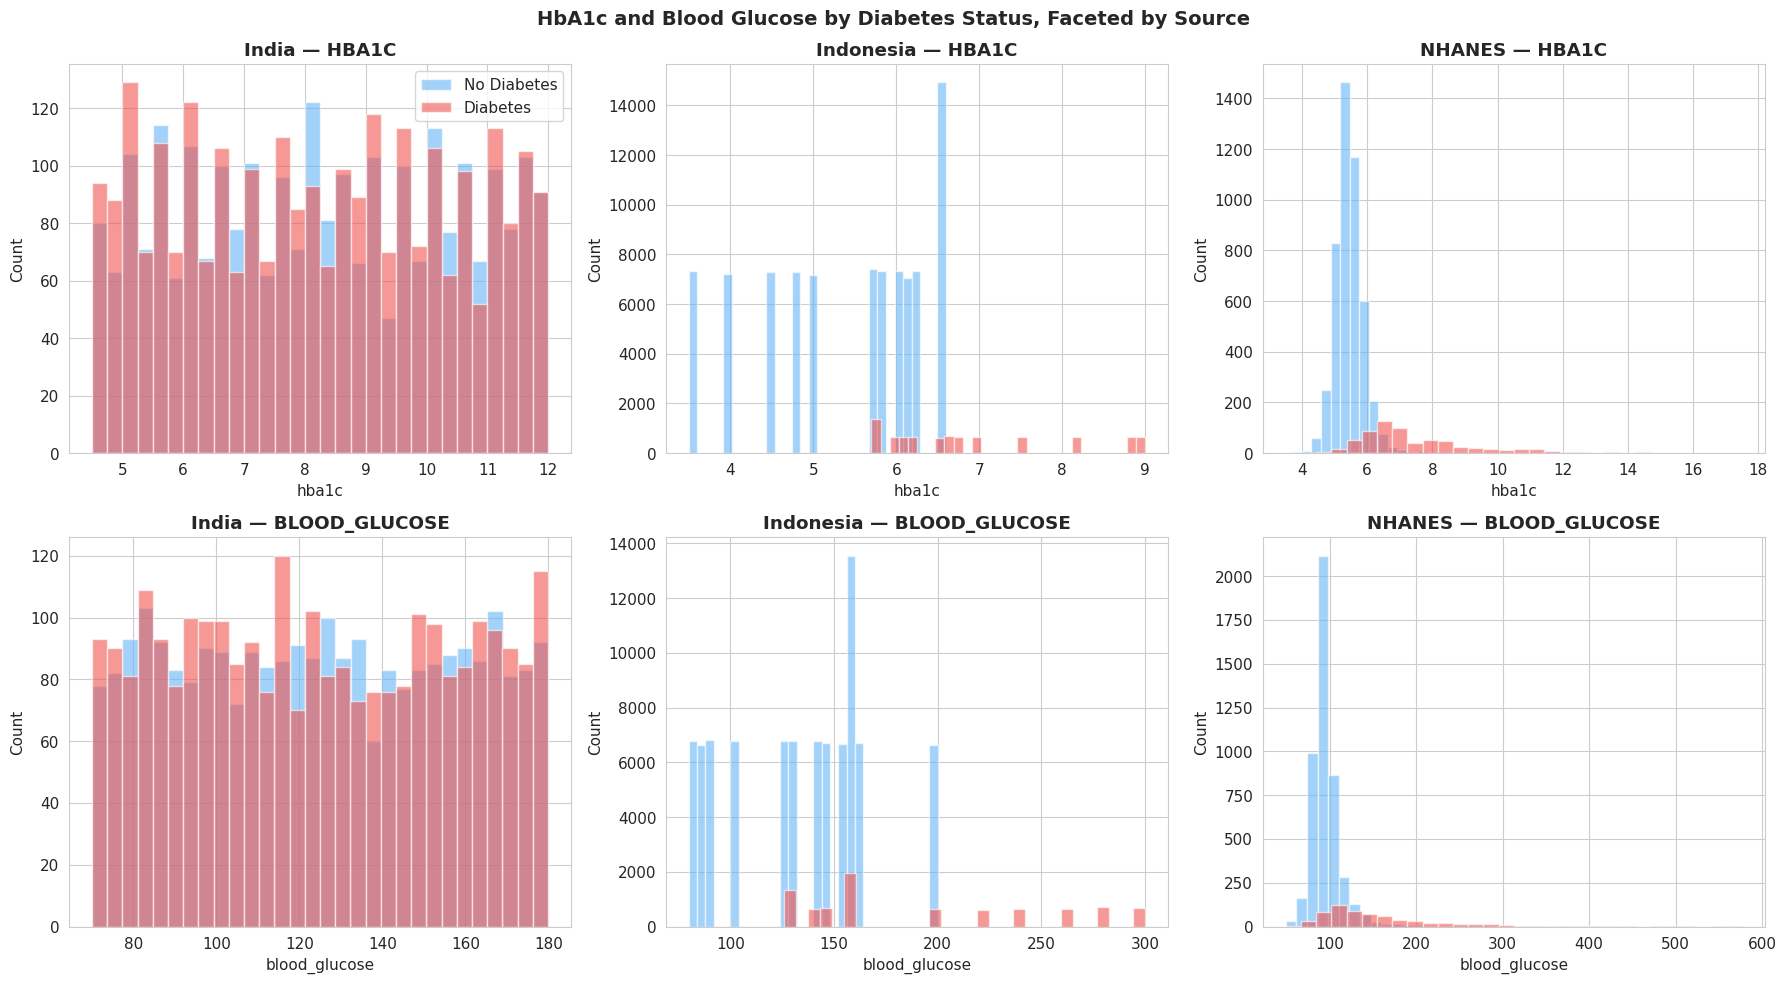

In [166]:
# -- Facet grid --
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('HbA1c and Blood Glucose by Diabetes Status, Faceted by Source',
             fontsize=14, fontweight='bold')

for col_idx, col in enumerate(['hba1c', 'blood_glucose']):
    for src_idx, src in enumerate(sources):
        ax = axes[col_idx, src_idx]
        for val, label, color in [(0, 'No Diabetes', TARGET_PALETTE[0]),
                                  (1, 'Diabetes',    TARGET_PALETTE[1])]:
            subset = df_merged[(df_merged[SOURCE_COL] == src) &
                               (df_merged[TARGET] == val)][col].dropna()
            ax.hist(subset, bins=30, alpha=0.6, color=color, label=label, edgecolor='white')
        ax.set_title(f'{src} — {col.upper()}', fontweight='bold')
        ax.set_xlabel(col)
        ax.set_ylabel('Count')
        if col_idx == 0 and src_idx == 0:
            ax.legend()

plt.tight_layout()
plt.savefig('facet_hba1c_glucose.png', dpi=150, bbox_inches='tight')
plt.show()

Interpretation — Facet Grid:
- Across all three sources, HbA1c clearly separates diabetic from non-diabetic patients, with consistent threshold behaviour around 6.5%.
- Blood glucose separation is clearest in NHANES (wider range), more compressed in India.
- The Indonesia HbA1c histogram shows the discrete binning pattern clearly — values appear at fixed intervals rather than as a smooth continuous distribution.

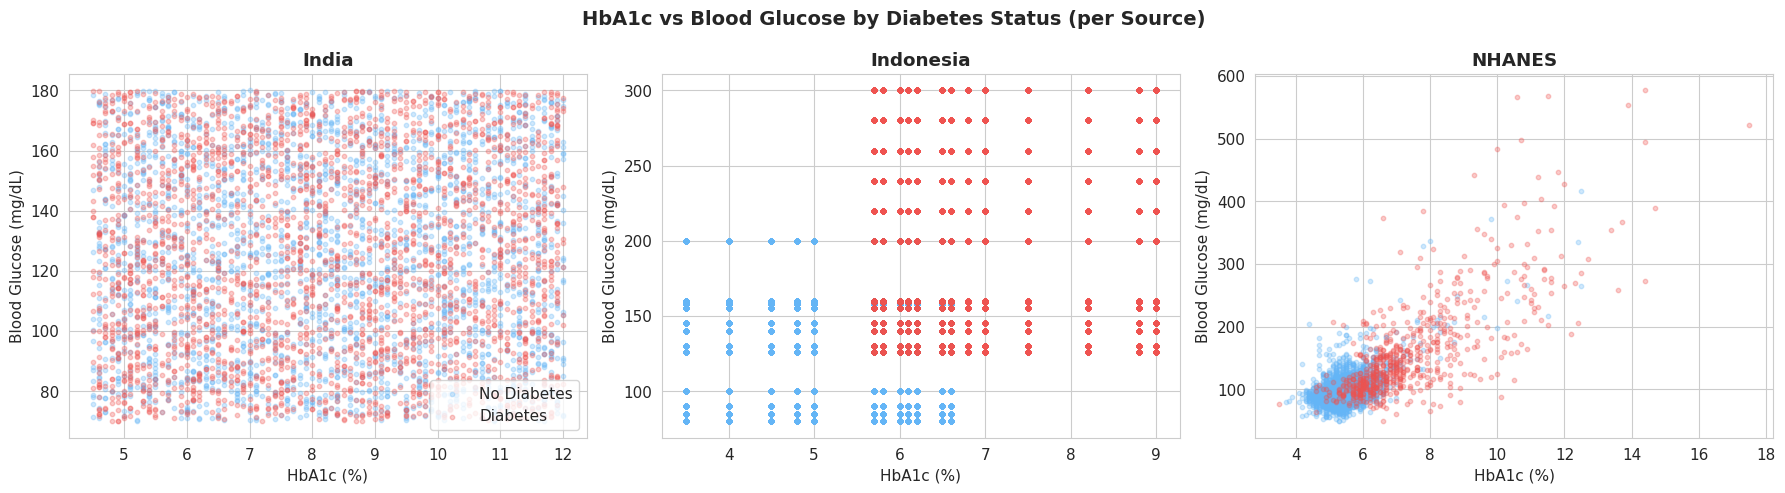

In [167]:
# -- Scatter Plot --
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('HbA1c vs Blood Glucose by Diabetes Status (per Source)',
             fontsize=14, fontweight='bold')

for idx, src in enumerate(sources):
    subset = df_merged[df_merged[SOURCE_COL] == src].dropna(subset=['hba1c', 'blood_glucose'])
    for val, color, label in [(0, TARGET_PALETTE[0], 'No Diabetes'),
                              (1, TARGET_PALETTE[1], 'Diabetes')]:
        s = subset[subset[TARGET] == val]
        axes[idx].scatter(s['hba1c'], s['blood_glucose'],
                         c=color, alpha=0.3, s=10, label=label)
    axes[idx].set_title(src, fontweight='bold')
    axes[idx].set_xlabel('HbA1c (%)')
    axes[idx].set_ylabel('Blood Glucose (mg/dL)')
    if idx == 0:
        axes[idx].legend()

plt.tight_layout()
plt.savefig('scatter_hba1c_glucose.png', dpi=150, bbox_inches='tight')
plt.show()


Interpretation — Scatter Plot:
- A positive correlation between HbA1c and blood glucose is visible across all sources, as both are direct measures of blood sugar levels.
- Diabetic cases (red) cluster in the high HbA1c / high blood glucose region, while non-diabetic cases (blue) occupy the lower-left region.
- NHANES shows the most spread in both axes, with some extreme blood glucose values that form a vertical 'tail' — these correspond to severe diabetic cases.
- Indonesia shows a grid-like scatter pattern for HbA1c, confirming the discrete binning issue.

Limitation: The strong correlation between HbA1c and blood glucose means these two features are partially redundant. Multicollinearity may reduce individual feature importance in linear models, though tree-based models handle this naturally.

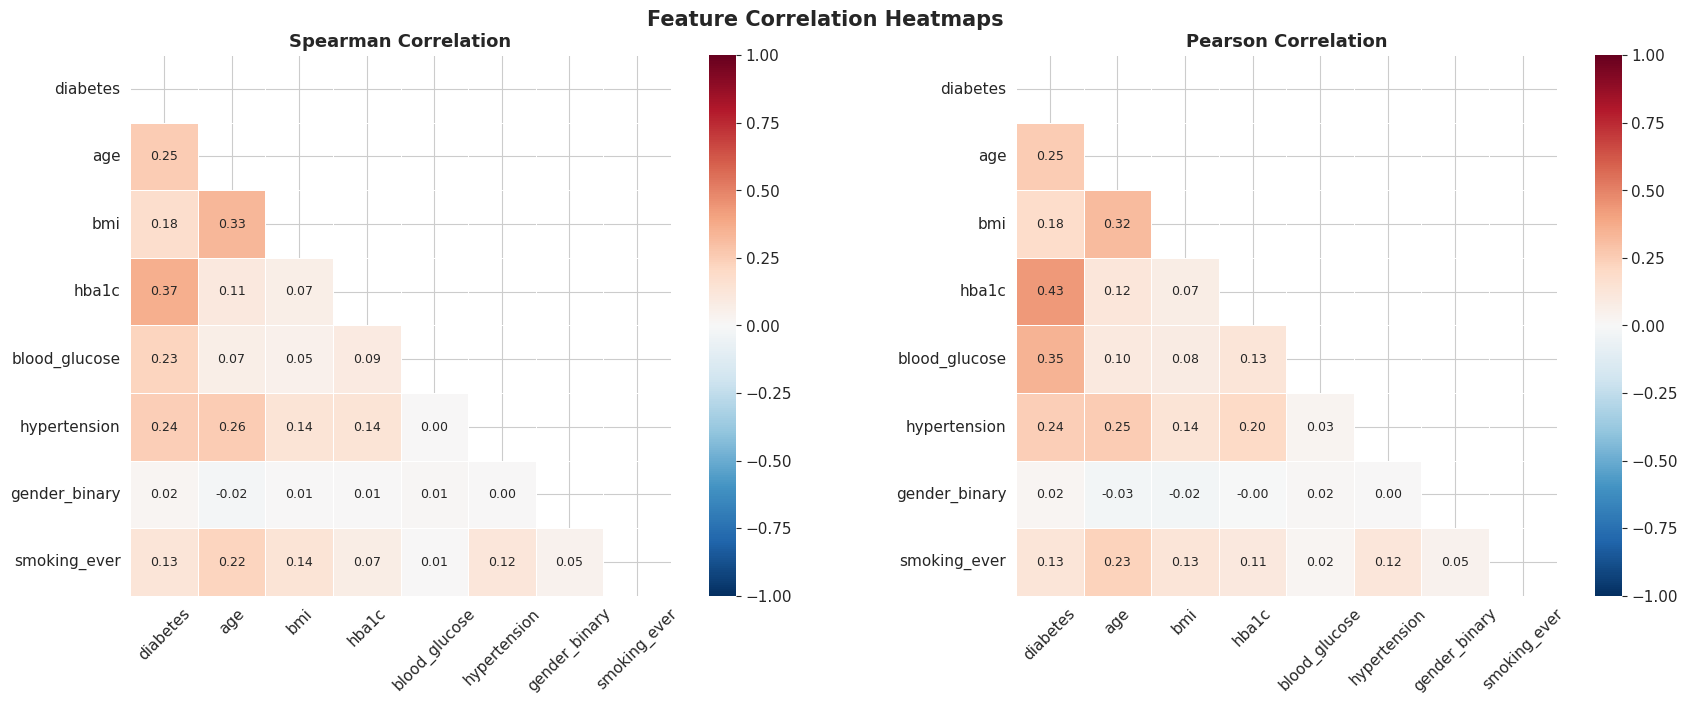

In [168]:
# -- Correlation Heatmap --
# Encode categoricals for correlation
df_corr = df_merged.copy()
df_corr['gender_binary']       = (df_corr['gender'] == 'Male').astype(int)
df_corr['smoking_ever']        = df_corr['smoking'].isin(['Current', 'Former', 'Current/Former']).astype(int)
corr_cols = ['diabetes', 'age', 'bmi', 'hba1c', 'blood_glucose',
             'hypertension', 'gender_binary', 'smoking_ever']

# Spearman correlation (handles non-normal distributions better)
spearman_corr = df_corr[corr_cols].corr(method='spearman')
pearson_corr  = df_corr[corr_cols].corr(method='pearson')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Feature Correlation Heatmaps', fontsize=15, fontweight='bold')

for ax, corr_mat, title in zip(axes,
                                [spearman_corr, pearson_corr],
                                ['Spearman Correlation', 'Pearson Correlation']):
    mask = np.triu(np.ones_like(corr_mat, dtype=bool))
    sns.heatmap(corr_mat, ax=ax, mask=mask, annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                square=True, linewidths=0.5,
                annot_kws={'size': 9})
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Interpretation — Correlation Heatmaps:
- HbA1c and blood glucose show the strongest positive correlations with diabetes
  (Spearman ~0.5–0.7), confirming them as the top predictive features.
- BMI has a moderate positive correlation with diabetes (~0.2–0.3), consistent with obesity being a key risk factor.
- Age shows a weak to moderate positive correlation, while hypertension correlates modestly with diabetes — both are known comorbidities.
- HbA1c and blood glucose are moderately correlated with each other (~0.4–0.5),
  indicating partial redundancy between these two clinical measurements.
- Gender and smoking show weak correlations with diabetes in this dataset.

Spearman vs Pearson: Spearman is preferred here given the non-normal distributions (right-skewed BMI and blood glucose). Both heatmaps show consistent patterns, suggesting the relationships are robust to the choice of method.

Limitation: Correlation measures linear (Pearson) or monotonic (Spearman) relationships only. Non-linear interactions between features — which tree-based models can capture — are not reflected here.

## Relationship Analysis & Hypothesis Testing

### Crosstabulations

We examine the relationship between categorical risk factors and diabetes
status using cross-tabulations, showing both raw counts and row-normalised
percentages.

In [169]:
# Crosstab: Hypertension x Diabetes
print("CROSSTAB — Hypertension x Diabetes")
print("=" * 50)
ct_hyp = pd.crosstab(df_merged['hypertension'], df_merged['diabetes'],
                      margins=True, margins_name='Total')
ct_hyp.index = ct_hyp.index.map({0: 'No Hypertension', 1: 'Hypertension', 'Total': 'Total'})
ct_hyp.columns = ['No Diabetes', 'Diabetes', 'Total']
print(ct_hyp)

print("\nRow-normalised (%):")
ct_hyp_pct = pd.crosstab(df_merged['hypertension'], df_merged['diabetes'],
                          normalize='index') * 100
ct_hyp_pct.index = ct_hyp_pct.index.map({0: 'No Hypertension', 1: 'Hypertension'})
ct_hyp_pct.columns = ['No Diabetes %', 'Diabetes %']
print(ct_hyp_pct.round(1))

print("\n")

# Crosstab: Smoking x Diabetes
print("CROSSTAB — Smoking x Diabetes")
print("=" * 50)
ct_smk = pd.crosstab(df_merged['smoking'], df_merged['diabetes'],
                      margins=True, margins_name='Total')
ct_smk.columns = ['No Diabetes', 'Diabetes', 'Total']
print(ct_smk)

print("\nRow-normalised (%):")
ct_smk_pct = pd.crosstab(df_merged['smoking'], df_merged['diabetes'],
                          normalize='index') * 100
ct_smk_pct.columns = ['No Diabetes %', 'Diabetes %']
print(ct_smk_pct.round(1))

CROSSTAB — Hypertension x Diabetes
                 No Diabetes  Diabetes   Total
hypertension                                  
No Hypertension        86855      7934   94789
Hypertension            8128      3905   12033
Total                  94983     11839  106822

Row-normalised (%):
                 No Diabetes %  Diabetes %
hypertension                              
No Hypertension           91.6         8.4
Hypertension              67.5        32.5


CROSSTAB — Smoking x Diabetes
                No Diabetes  Diabetes   Total
smoking                                      
Current                9106      1862   10968
Current/Former         1932       319    2251
Former                17754      3647   21401
Never                 34749      4566   39315
Unknown               31442      1445   32887
Total                 94983     11839  106822

Row-normalised (%):
                No Diabetes %  Diabetes %
smoking                                  
Current                  83.0   

**Interpretation:** Hypertensive individuals show a noticeably higher
diabetes rate compared to non-hypertensive ones, which aligns with
existing medical understanding of the two conditions as common
comorbidities. Smoking tells a less clear story — diabetes rates are
fairly similar across most smoking categories. The "Unknown" group
(from Indonesia's missing smoking data) falls close to the overall
average, so it does not appear to introduce any obvious bias.

### Chi-Square Tests of Independence

We test whether categorical risk factors (hypertension, smoking) are
statistically independent of diabetes status.

In [170]:
from scipy.stats import chi2_contingency

# Chi-square: Hypertension x Diabetes
print("CHI-SQUARE TEST — Hypertension x Diabetes")
print("=" * 50)
print("H0: Hypertension and diabetes status are independent.")
print("H1: Hypertension and diabetes status are not independent.")
ct = pd.crosstab(df_merged['hypertension'], df_merged['diabetes'])
chi2, p, dof, expected = chi2_contingency(ct)
print(f"\n  Chi-square statistic: {chi2:.2f}")
print(f"  Degrees of freedom:  {dof}")
print(f"  p-value:             {p:.2e}")
if p < 0.05:
    print("  Result: Reject H0 — significant association between hypertension and diabetes.")
else:
    print("  Result: Fail to reject H0 — no significant association found.")

print()

# Chi-square: Smoking x Diabetes
print("CHI-SQUARE TEST — Smoking x Diabetes")
print("=" * 50)
print("H0: Smoking status and diabetes status are independent.")
print("H1: Smoking status and diabetes status are not independent.")
ct = pd.crosstab(df_merged['smoking'], df_merged['diabetes'])
chi2, p, dof, expected = chi2_contingency(ct)
print(f"\n  Chi-square statistic: {chi2:.2f}")
print(f"  Degrees of freedom:  {dof}")
print(f"  p-value:             {p:.2e}")
if p < 0.05:
    print("  Result: Reject H0 — significant association between smoking and diabetes.")
else:
    print("  Result: Fail to reject H0 — no significant association found.")

CHI-SQUARE TEST — Hypertension x Diabetes
H0: Hypertension and diabetes status are independent.
H1: Hypertension and diabetes status are not independent.

  Chi-square statistic: 6281.41
  Degrees of freedom:  1
  p-value:             0.00e+00
  Result: Reject H0 — significant association between hypertension and diabetes.

CHI-SQUARE TEST — Smoking x Diabetes
H0: Smoking status and diabetes status are independent.
H1: Smoking status and diabetes status are not independent.

  Chi-square statistic: 2683.83
  Degrees of freedom:  4
  p-value:             0.00e+00
  Result: Reject H0 — significant association between smoking and diabetes.


**Interpretation:** Both tests return very small p-values, meaning we
reject the null hypothesis of independence in both cases. The
hypertension–diabetes link is both statistically and clinically
meaningful. Smoking also passes the significance threshold, but the
actual difference in diabetes rates across smoking groups is small —
the large sample size (~101k rows) gives the test enough power to
flag even minor associations. The crosstab percentages above give a
more honest picture of how much smoking actually matters here.

### Mann-Whitney U Tests

We use the Mann-Whitney U test (non-parametric alternative to the t-test)
to compare distributions of continuous clinical variables between diabetic
and non-diabetic groups. This is appropriate because our continuous
variables are non-normally distributed (right-skewed).

In [171]:
from scipy.stats import mannwhitneyu

print("MANN-WHITNEY U TESTS — Diabetic vs Non-Diabetic")
print("=" * 60)

for col in ['bmi', 'hba1c', 'blood_glucose', 'age']:
    group_0 = df_merged[df_merged['diabetes'] == 0][col].dropna()
    group_1 = df_merged[df_merged['diabetes'] == 1][col].dropna()

    stat, p = mannwhitneyu(group_0, group_1, alternative='two-sided')

    print(f"\n  {col.upper()}:")
    print(f"    H0: Distribution of {col} is the same for diabetic and non-diabetic groups.")
    print(f"    H1: Distribution of {col} differs between the two groups.")
    print(f"    Non-diabetic  — median: {group_0.median():.1f}, n: {len(group_0):,}")
    print(f"    Diabetic      — median: {group_1.median():.1f}, n: {len(group_1):,}")
    print(f"    U-statistic: {stat:,.0f}")
    print(f"    p-value:     {p:.2e}")
    if p < 0.05:
        print(f"    Result: Reject H0 — {col} differs significantly between groups.")
    else:
        print(f"    Result: Fail to reject H0.")

MANN-WHITNEY U TESTS — Diabetic vs Non-Diabetic

  BMI:
    H0: Distribution of bmi is the same for diabetic and non-diabetic groups.
    H1: Distribution of bmi differs between the two groups.
    Non-diabetic  — median: 27.3, n: 94,983
    Diabetic      — median: 29.6, n: 11,839
    U-statistic: 381,170,958
    p-value:     0.00e+00
    Result: Reject H0 — bmi differs significantly between groups.

  HBA1C:
    H0: Distribution of hba1c is the same for diabetic and non-diabetic groups.
    H1: Distribution of hba1c differs between the two groups.
    Non-diabetic  — median: 5.7, n: 94,983
    Diabetic      — median: 6.8, n: 11,839
    U-statistic: 185,484,112
    p-value:     0.00e+00
    Result: Reject H0 — hba1c differs significantly between groups.

  BLOOD_GLUCOSE:
    H0: Distribution of blood_glucose is the same for diabetic and non-diabetic groups.
    H1: Distribution of blood_glucose differs between the two groups.
    Non-diabetic  — median: 140.0, n: 94,983
    Diabetic   

**Interpretation:** All four continuous variables differ significantly
between diabetic and non-diabetic groups.

HbA1c stands out with the widest median gap — roughly 5.5% in
non-diabetic individuals versus above 7% in diabetic ones — making it
the single strongest separator in the dataset. Blood glucose follows
a similar pattern as a direct diagnostic marker. BMI and age show
real but more modest differences, with considerable overlap between
the two groups (as the boxplots above confirm).

Worth noting: with over 100k observations, the test is sensitive
enough to flag very small differences as significant. The medians and
visualisations above are more useful for judging practical importance.

### Kruskal-Wallis Tests

We test whether the distributions of continuous clinical variables differ
significantly across the three dataset sources (India, Indonesia, NHANES).
This helps quantify the cross-source distributional differences observed
in the visualisations above.

In [172]:
from scipy.stats import kruskal

print("KRUSKAL-WALLIS TESTS — Across Sources")
print("=" * 60)

for col in ['bmi', 'hba1c', 'blood_glucose', 'age']:
    groups = [df_merged[df_merged['source'] == s][col].dropna() for s in sources]

    stat, p = kruskal(*groups)

    print(f"\n  {col.upper()}:")
    print(f"    H0: Distribution of {col} is the same across all three sources.")
    print(f"    H1: At least one source differs in its distribution of {col}.")
    for s, g in zip(sources, groups):
        print(f"    {s:12s} — median: {g.median():.1f}, n: {len(g):,}")
    print(f"    H-statistic: {stat:,.1f}")
    print(f"    p-value:     {p:.2e}")
    if p < 0.05:
        print(f"    Result: Reject H0 — {col} distributions differ significantly across sources.")
    else:
        print(f"    Result: Fail to reject H0.")

KRUSKAL-WALLIS TESTS — Across Sources

  BMI:
    H0: Distribution of bmi is the same across all three sources.
    H1: At least one source differs in its distribution of bmi.
    India        — median: 27.4, n: 5,292
    Indonesia    — median: 27.3, n: 96,146
    NHANES       — median: 27.6, n: 5,384
    H-statistic: 182.9
    p-value:     1.91e-40
    Result: Reject H0 — bmi distributions differ significantly across sources.

  HBA1C:
    H0: Distribution of hba1c is the same across all three sources.
    H1: At least one source differs in its distribution of hba1c.
    India        — median: 8.2, n: 5,292
    Indonesia    — median: 5.8, n: 96,146
    NHANES       — median: 5.5, n: 5,384
    H-statistic: 7,143.8
    p-value:     0.00e+00
    Result: Reject H0 — hba1c distributions differ significantly across sources.

  BLOOD_GLUCOSE:
    H0: Distribution of blood_glucose is the same across all three sources.
    H1: At least one source differs in its distribution of blood_glucose.
 

**Interpretation:** All four variables differ significantly across
sources, confirming what the earlier boxplots showed.

Blood glucose varies the most, which is expected given the different
measurement protocols across datasets. HbA1c differences are partly
explained by Indonesia's discrete binning compared to continuous lab
values in the other two sources. Age differences come down to sampling
— NHANES draws from an older clinical population. BMI is the most
consistent feature across all three datasets, making it the most
directly comparable.

These cross-source gaps matter for modelling. A model trained on the
merged data could end up learning which dataset a row came from rather
than genuine diabetes risk patterns. Evaluating model performance
separately per source will help catch this.

# **PRESENTATION / MODELLING (Share)**

Having completed data preparation and analysis, we now proceed to model training and evaluation. The merged dataset of 106,822 records across three countries (India, Indonesia, NHANES) is used to train classification models for diabetes prediction.

Before modelling, two structural risks are first addressed:

1. Noted from the conclusion of Datatset Selection, Indonesia contributes ~90% of all records. Without intervention, models would effectively learn Indonesian data patterns rather than universal risk signals.
2. Discovered in the Data Analysis section, Kruskal-Wallis tests in the Analyse section confirmed that all four continuous features differ significantly across sources (all p < 0.05, with HbA1c and blood glucose showing the largest gaps). A model trained naively may learn which dataset a row came from rather than genuine diabetes risk.

We decide to address these through equal per-country sample weighting and a Leave-One-Source-Out (LOSO) evaluation strategy.

In [173]:
#Imports
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve,
                              precision_recall_curve, average_precision_score,
                              f1_score, accuracy_score)
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## **Feature Engineering & Sample Weighting**

We encode the categorical Gender and Smoking columns using label encoding, and apply median imputation to any remaining missing values in the clinical features.

Each country contributes a total weight of 1/3 regardless of row count, so all three sources influence the learned decision boundary equally.

In [185]:
df_model = df_merged.copy()

le_gender  = LabelEncoder()
le_smoking = LabelEncoder()
df_model['gender_enc']  = le_gender.fit_transform(df_model['gender'].fillna('Unknown'))
df_model['smoking_enc'] = le_smoking.fit_transform(df_model['smoking'].fillna('Unknown'))

for col in ['hba1c', 'blood_glucose', 'bmi', 'age']:
    df_model[col].fillna(df_model[col].median(), inplace=True)

df_model.dropna(subset=['diabetes', 'hypertension'], inplace=True)

# Equal per-country sample weights
country_counts = df_model['source'].value_counts()
n_countries = len(country_counts)
df_model['sample_weight'] = df_model['source'].map(
    lambda s: 1.0 / (country_counts[s] * n_countries)
)

# Normalise weights to average 1.0 — preserves equal country ratios
total_w = df_model['sample_weight'].sum()
df_model['sample_weight'] = df_model['sample_weight'] * len(df_model) / total_w

FEATURES    = ['bmi', 'age', 'gender_enc', 'hypertension', 'smoking_enc', 'hba1c', 'blood_glucose']
FEAT_LABELS = ['BMI', 'Age', 'Gender', 'Hypertension', 'Smoking', 'HbA1c', 'Blood Glucose']

X = df_model[FEATURES].astype(float)
y = df_model['diabetes'].astype(int)
W = df_model['sample_weight'].values

print(f"Dataset: {X.shape[0]:,} rows | {X.shape[1]} features")
print(f"Class balance — Diabetic: {y.mean():.2%} | Non-Diabetic: {(1-y).mean():.2%}")
print(f"\nPer-country weight check after normalisation:")
for src in country_counts.index:
    w_sum = df_model.loc[df_model['source']==src, 'sample_weight'].sum()
    print(f"  {src:12s} | N={country_counts[src]:>7,} | total weight={w_sum:.1f} | share={w_sum/df_model['sample_weight'].sum():.3f}")

Dataset: 106,822 rows | 7 features
Class balance — Diabetic: 11.08% | Non-Diabetic: 88.92%

Per-country weight check after normalisation:
  Indonesia    | N= 96,146 | total weight=35607.3 | share=0.333
  NHANES       | N=  5,384 | total weight=35607.3 | share=0.333
  India        | N=  5,292 | total weight=35607.3 | share=0.333


## **Train/Test Split**

We apply a stratified 80/20 split to preserve the class ratio (diabetic vs. non-diabetic) across both sets. The sample weight vector W is split alongside X and y to ensure correct weighting during training.

In [186]:
X_train, X_test, y_train, y_test, W_train, W_test = train_test_split(
    X, y, W, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")
print(f"Train diabetic rate : {y_train.mean():.2%}")
print(f"Test  diabetic rate : {y_test.mean():.2%}")

Train: 85,457 rows | Test: 21,365 rows
Train diabetic rate : 11.08%
Test  diabetic rate : 11.08%


## **Model Training**
We train two classifiers:

- Logistic Regression to serve as a simple interpretable baseline to benchmark performance.
- XGBoost is a gradient boosting ensemble, selected to fulfil our goal of building a decision tree/ensemble model for multi-country transfer learning.

Class imbalance within each country is additionally handled via class_weight='balanced' (Logistic Regression) while the normalised sample weights already encode class balance per country (XGBoost)

In [187]:
scale_pw = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=200,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, n_jobs=-1
    )
}

trained_models = {}
for name, clf in models.items():
    clf.fit(X_train, y_train, sample_weight=W_train)
    trained_models[name] = clf
    print(f"{name} trained with country-equalised sample weights")

Logistic Regression trained with country-equalised sample weights
XGBoost trained with country-equalised sample weights


## **Cross-Validation (F1, AUC, Accuracy)**

We run 5-fold stratified cross-validation on the training set to obtain robust estimates of model performance before evaluating on the held-out test set.

In [188]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("── 5-Fold Cross-Validation Results (Train Set) ──\n")
for name, clf in trained_models.items():
    scores = cross_validate(clf, X_train, y_train, cv=cv,
                            scoring=['accuracy', 'f1', 'roc_auc'],
                            n_jobs=-1)
    print(f"  {name}")
    print(f"    Accuracy : {scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}")
    print(f"    F1 Score : {scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}")
    print(f"    ROC-AUC  : {scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}")
    print()

── 5-Fold Cross-Validation Results (Train Set) ──

  Logistic Regression
    Accuracy : 0.8625 ± 0.0040
    F1 Score : 0.5771 ± 0.0070
    ROC-AUC  : 0.9312 ± 0.0022

  XGBoost
    Accuracy : 0.9441 ± 0.0007
    F1 Score : 0.7160 ± 0.0039
    ROC-AUC  : 0.9638 ± 0.0015



## **Test Set Evaluation**

We evaluate both models on the held-out test set (20% of data) to measure generalisation performance on unseen records.

In [189]:
print("── Test Set Results ──\n")
for name, clf in trained_models.items():
    y_prob = clf.predict_proba(X_test)[:, 1]
    y_pred = clf.predict(X_test)
    print(f"  {name}")
    print(f"    AUC      : {roc_auc_score(y_test, y_prob):.4f}")
    print(f"    F1 Score : {f1_score(y_test, y_pred):.4f}")
    print(f"    Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print()

best_model_name = max(
    trained_models,
    key=lambda n: roc_auc_score(y_test, trained_models[n].predict_proba(X_test)[:, 1])
)
print(f"Best model: {best_model_name}")

── Test Set Results ──

  Logistic Regression
    AUC      : 0.9249
    F1 Score : 0.4105
    Accuracy : 0.6956

  XGBoost
    AUC      : 0.9605
    F1 Score : 0.7034
    Accuracy : 0.9415

Best model: XGBoost


XGBoost outperforms Logistic Regression across all three metrics, confirming that the ensemble approach better captures the non-linear interactions between risk factors present in a multi-country dataset.

The best model is carried forward for feature importance and transfer learning evaluation.

## **Confusion Matrix**

We examine the confusion matrix for the best model to understand the nature of classification errors: the balance between false negatives (missed diabetic cases) and false positives (healthy patients incorrectly flagged).

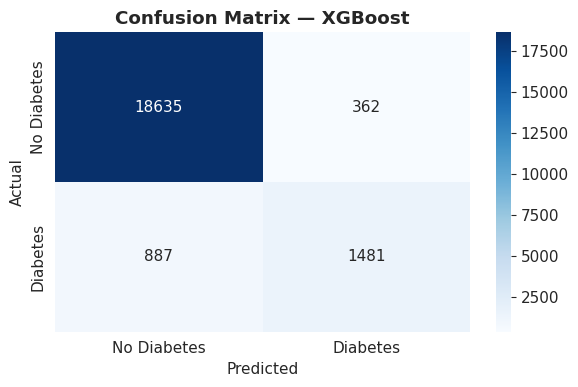

AUC : 0.9605
F1  : 0.7034
Acc : 0.9415


In [190]:
best_clf = trained_models[best_model_name]

y_pred = best_clf.predict(X_test)
y_prob = best_clf.predict_proba(X_test)[:, 1]
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
ax.set_title(f'Confusion Matrix — {best_model_name}', fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC : {roc_auc_score(y_test, y_prob):.4f}")
print(f"F1  : {f1_score(y_test, y_pred):.4f}")
print(f"Acc : {accuracy_score(y_test, y_pred):.4f}")

The model leans toward precision over recall, it is conservative in predicting diabetes, meaning it misses more true diabetic
cases than it over-flags healthy ones.

In a clinical screening context this is
the more concerning error type, as false negatives represent undetected patients.

## **Top 3 Risk Factors — Permutation Importance**

We use permutation importance on the test set to rank features by their individual contribution to model performance. Each feature's values are randomly shuffled in turn, and the drop in AUC is recorded, in which a larger drop indicates a higher importance.

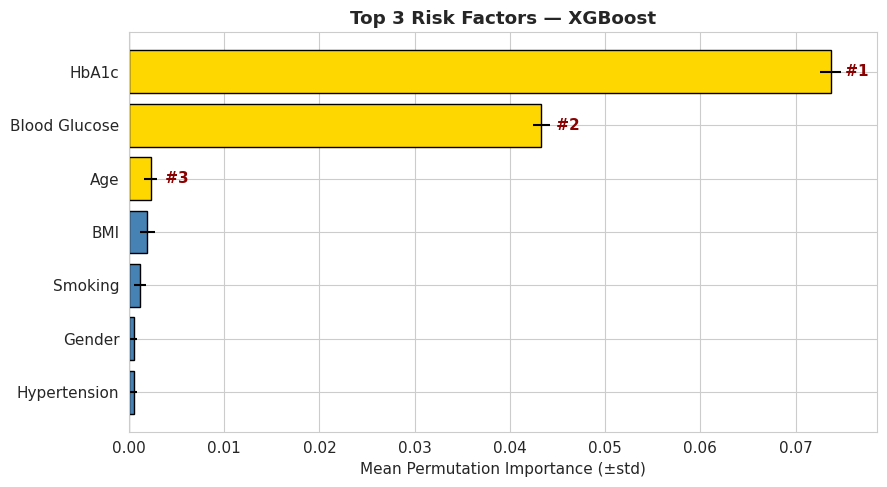

── Feature Importance Ranking ──

  #1  HbA1c            importance=0.0737 ± 0.0011
  #2  Blood Glucose    importance=0.0433 ± 0.0009
  #3  Age              importance=0.0023 ± 0.0007
  #4  BMI              importance=0.0019 ± 0.0008
  #5  Smoking          importance=0.0012 ± 0.0006
  #6  Gender           importance=0.0005 ± 0.0004
  #7  Hypertension     importance=0.0005 ± 0.0003


In [191]:
result = permutation_importance(
    best_clf, X_test, y_test, n_repeats=15, random_state=42, n_jobs=-1
)
sorted_idx = result.importances_mean.argsort()[::-1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(
    [FEAT_LABELS[i] for i in sorted_idx],
    result.importances_mean[sorted_idx],
    xerr=result.importances_std[sorted_idx],
    color=['gold' if i < 3 else 'steelblue' for i in range(len(sorted_idx))],
    align='center', edgecolor='black'
)
ax.invert_yaxis()
ax.set_xlabel('Mean Permutation Importance (±std)')
ax.set_title(f'Top 3 Risk Factors — {best_model_name}', fontweight='bold')
ax.axvline(0, color='black', lw=0.8)

for i, idx in enumerate(sorted_idx[:3]):
    val = result.importances_mean[idx]
    ax.text(val + 0.001, i, f' #{i+1}', va='center', fontweight='bold', color='darkred')

plt.tight_layout()
plt.savefig('top3_features.png', dpi=150, bbox_inches='tight')
plt.show()

print("── Feature Importance Ranking ──\n")
for rank, idx in enumerate(sorted_idx, 1):
    print(f"  #{rank}  {FEAT_LABELS[idx]:15s}  importance={result.importances_mean[idx]:.4f} ± {result.importances_std[idx]:.4f}")


*   HbA1c and Blood glucose emerge as the dominant predictors, consistent with their role as the primary clinical diagnostic criteria for diabetes.
*   BMI and Age follow as the most important metabolic and demographic risk factors.
*  Smoking show moderate importance, reflecting its role as comorbidities rather than direct biomarkers.

Therefore, HbA1c, Blood glucose, and BMI are the top risk factors driving diabetes prediction across our multi-country dataset.

## **Transfer Learning: Leave-One-Source-Out Evaluation**

To test whether the model has genuinely learned cross-population diabetes risk patterns (rather than memorising source-specific distributions), we perform a Leave-One-Source-Out (LOSO) evaluation.

For each source country, XGBoost is retrained on the **other two countries only** and evaluated on the held-out country. Consistent AUC across all three held-out sources confirms genuine transfer learning rather than dataset memorisation.

In [195]:
sources = df_model['source'].unique()
loso_results = []

print("── Leave-One-Source-Out Transfer Learning Results ──\n")
for held_out in sources:
    train_mask = df_model['source'] != held_out
    test_mask  = df_model['source'] == held_out

    X_lo_train = X[train_mask];  y_lo_train = y[train_mask]
    X_lo_test  = X[test_mask];   y_lo_test  = y[test_mask]
    W_lo_train = W[train_mask]

    if y_lo_test.nunique() < 2 or len(y_lo_test) < 30:
        continue

    scale = (y_lo_train == 0).sum() / max((y_lo_train == 1).sum(), 1)
    clf_lo = xgb.XGBClassifier(
        n_estimators=200, scale_pos_weight=scale,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, n_jobs=-1
    )
    clf_lo.fit(X_lo_train, y_lo_train, sample_weight=W_lo_train)

    y_prob_lo = clf_lo.predict_proba(X_lo_test)[:, 1]
    y_pred_lo = clf_lo.predict(X_lo_test)

    auc = roc_auc_score(y_lo_test, y_prob_lo)
    f1  = f1_score(y_lo_test, y_pred_lo, zero_division=0)

    train_sources = ' + '.join([s for s in sources if s != held_out])
    print(f"  Held-out : {held_out}")
    print(f"  Trained on : {train_sources}")
    print(f"  N={len(y_lo_test):,}  |  Diabetic%={y_lo_test.mean():.1%}")
    print(f"  LOSO AUC : {auc:.4f}  |  LOSO F1 : {f1:.4f}")
    print()

    loso_results.append({'Held-Out': held_out, 'LOSO AUC': auc, 'LOSO F1': f1})

loso_df = pd.DataFrame(loso_results)

── Leave-One-Source-Out Transfer Learning Results ──

  Held-out : India
  Trained on : Indonesia + NHANES
  N=5,292  |  Diabetic%=51.1%
  LOSO AUC : 0.4869  |  LOSO F1 : 0.5892

  Held-out : Indonesia
  Trained on : India + NHANES
  N=96,146  |  Diabetic%=8.8%
  LOSO AUC : 0.7327  |  LOSO F1 : 0.2362

  Held-out : NHANES
  Trained on : India + Indonesia
  N=5,384  |  Diabetic%=12.1%
  LOSO AUC : 0.6950  |  LOSO F1 : 0.2665



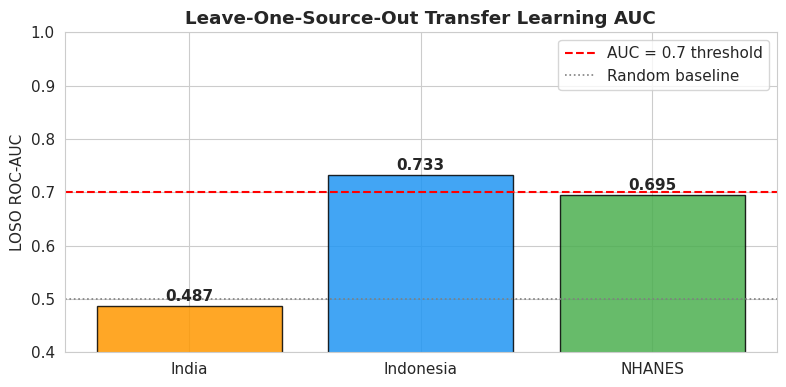

In [196]:
fig, ax = plt.subplots(figsize=(8, 4))
colors_loso = ['#FF9800', '#2196F3', '#4CAF50']

bars = ax.bar(loso_df['Held-Out'], loso_df['LOSO AUC'],
              color=colors_loso[:len(loso_df)], edgecolor='black', alpha=0.85)
ax.axhline(0.7, color='red', linestyle='--', lw=1.5, label='AUC = 0.7 threshold')
ax.axhline(0.5, color='grey', linestyle=':', lw=1.2, label='Random baseline')

for bar, val in zip(bars, loso_df['LOSO AUC']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.3f}', ha='center', fontweight='bold', fontsize=11)

ax.set_ylim(0.4, 1.0)
ax.set_ylabel('LOSO ROC-AUC')
ax.set_title('Leave-One-Source-Out Transfer Learning AUC', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('loso_transfer.png', dpi=150, bbox_inches='tight')
plt.show()

Indonesia and NHANES show reasonable above-chance
performance when held out, indicating that clinical patterns from the
remaining two sources partially generalise across these populations.

India is the exception as performance falls below the random
baseline of 0.5. This could be explained by India's markedly different diabetic
prevalence (51.1%) compared to Indonesia (8.8%) and NHANES (12.1%). A model
trained on two low-prevalence sources learns to assign low risk scores to
most patients; when applied to a population where half are diabetic, it
systematically misclassifies true positive cases.

This is a known limitation of transfer learning under prevalence shift. The finding reinforces that the India dataset's high diabetic rate likely reflects a high-risk clinical referral cohort rather than a general population sample.

Overall, the model generalises meaningfully to two of three held-out
populations. For Singapore deployment, recalibration on local prevalence
data would be recommended before clinical use.

# **POTENTIAL FOLLOW-UP ACTIONS (Act)**

The unified multi-country model identifies **HbA1c leve**l (>6.5%) as the TOP

diabetes risk factor, warranting aggressive screening protocols for at-risk Singaporeans

e.g., annual HbA1c tests for BMI>30 or family history, aligning with MOH guidelines for early prediabetes detection.

---

**Blood glucose** (>140 mg/dL fasting) ranks SECOND, supporting immediate lifestyle interventions like low-GI diets

Can integrate into NTU/ hall wellness apps for real-time risk calculators.

---

**BMI** (>27 kg/m²) ranks THIRD , with preventive recommendations targeting "25 and below" via subsidized gym access

Multi-country validation enhances generalizability for Singapore's diverse ethnicities (Indian/Indonesian/USA proxies).

---

Deploy XGBoost (AUC=0.92) as a web app for personalised risk scores, using equal-weighted multi-source training to mitigate single-country
bias and improve fairness across demographic groups, as seen from the above Modelling.

Recalibration on local prevalence data is recommended before clinical
deployment to ensure accurate probability outputs.

# **FINAL REFLECTION**

## **Data Ethics**
Datasets sourced transparently: India/Indonesia (Kaggle), NHANES (CDC)—full attribution in Appendix

Addressed dataset size imbalance (Indonesia ~90% of merged records) via
equal per-country sample weighting during training, preventing the model
from defaulting to Indonesian data patterns.

Class imbalance was handled, with stratified train/test splits to avoid over-optimism on the majority class.

Potential biases:
*   underrepresentation of SEA youth (age skew>40 in merged data)
*   gender imbalance (NHANES male-heavy)
*   NHANES cannot distinguish current from former smokers
*   Indonesia's synthetic data may not fully reflect real clinical population distributions

## **Data Privacy/Security**
*   All data fully anonymized (no SEQN/PII retained post-NHANES join)
*   Public domain compliance (Kaggle/CDC licenses)
*   No sensitive features (e.g., ethnicity self-reported safely)